# Companies House - Logistic Regression

This script concentrates on creating and running the logistic regression model using data created and saved in *CH_EDA_and_Cleansing.pynb*.

Some helper functions have been defined in *utils.py* and *visualisations.py* to ensure that this script is shorter.

The cleaned and prepared dataset was saved locally as a Parquet file in a *CH_EDA_and_Cleansing.pynb* for use in this and any future scripts to enable faster, more secure loading as original data was **~5.5 million rows**, which was then reduced down into a modelling dataset of **~2.8 million rows**.

This script loads the data into a DataFrame and then:
1. Reduces the dataset size by taking a sample of the data for speed of processing the logistic regression modelling.
2. Splits the sample data into "training" and "testing" datasets.
3. Explores each variable against the late-rate within the "training" dataset, refining which variables show predictive power and those that don't.
4. Check for multicollinearity within the remaining columns.
5. Builds the logistic regression model using the training dataset, conducting threshold tuning.
6. Tests the logisitc regression model using the testing dataset.
7. Analyses the coefficients to assess which variables have the most and least predictive power.
8. Explores the logistic regression against completely unseen data (df_discard from step 1).
9. Creates a population profile for the *high-risk* population identified by the logistic regression model.


The aim of this logistic regression model is to predict the probability that a company is likely to file late Companies House accounts when considering their company structure and governance features by comparing them to the late-filing history of other companies with similar features.

## 1. Libraries and Data Loading

In [1]:
# ---------------------------------------------------------
# Library imports
# ---------------------------------------------------------

# Standard library
import os                                         # File and directory operations
import sys                                        # Gives access to Python's system-level variables and functions
sys.path.append(os.path.abspath(".."))            # Needed so the notebook can find src/

# Data handling tools
import pandas as pd
import numpy as np
from IPython.display import Markdown
# File handling
from pathlib import Path

# Modelling preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Logistic Regression model running tools
from sklearn.linear_model import LogisticRegression

# Evaluation Metric tools
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    roc_auc_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    auc
)

# Visualisation Tools
import matplotlib.pyplot as plt
import seaborn as sns
#import matplotlib.ticker as mtick

# Import src helper functions
from src import (
    find_project_root,                # Dataset summary helper (utils.py)
    print_dataset_shape,              # Prints the rows and columns in the dataset
    value_counts_table,               # producing value‑count tables with percentages helper (utils.py)
    drop_columns_and_report,          # dropping columns with a shape check helper (utils.py)
    map_categories,                   # mapping messy category labels to cleaner groups helper (utils.py)  
    plot_numeric_distribution,        # bar-chart distribution of numeric values helper (visualisations.py)
    plot_interactive_pr_curve,        # interactive precision recall curve with hover labels helper (visualisations.py)
    plot_late_rate_by_category_grid,  # plotting distributions and category-level late rates helper (visualisations.py)
    plot_categorical_association,     # heatmap of Cramer's V across categorical columns) helper (visualisations.py)
    plot_correlation_matrix           # plotting correlation matrices (numeric + categorical) helper (visualisations.py)
)

#### Load the final modelling dataset from its local file storage path.

In [2]:
# Define the base directory for the project
# this is used to create all other file paths
BASE_DIR = find_project_root(Path.cwd())

# Define the directory structure for raw and processed data
data_dir = BASE_DIR / "Companies_House"
processed_dir = data_dir / "data_processed"
model_ready_data_path = processed_dir / "model_ready_data.parquet"

In [3]:
# Load the final modelling dataset
df = pd.read_parquet(model_ready_data_path)
df.head(10)

,company_category,accounts_group,registered_country,industry,company_age_when_acc_due,psc_count,has_corporate_psc,has_foreign_psc,recent_psc_change,overdue
0,LTD,SIMPLEST,ENGLAND,Admin & Support Services,5–10,1,0,1,0,0
1,LTD,REDUCED,ENGLAND,Information & Communication,5–10,3,0,1,0,0
2,LTD,SIMPLEST,UK,Accommodation & Food,5–10,2,0,1,0,1
3,LTD,SIMPLEST,ENGLAND,Admin & Support Services,5–10,1,0,1,0,0
4,LTD,MINIMAL,UNKNOWN,Wholesale & Retail,10–20,1,1,1,0,0
5,LTD,MINIMAL,ENGLAND,Wholesale & Retail,2–5,1,0,1,0,0
6,LTD,SIMPLEST,UK,Real Estate,2–5,2,0,0,0,0
7,LTD,SIMPLEST,ENGLAND,Information & Communication,10–20,2,0,1,0,0
8,LTD,SIMPLEST,UK,Real Estate,20+,2,0,1,0,0
9,LTD,SIMPLEST,ENGLAND,Wholesale & Retail,20+,2,0,1,0,0


In [4]:
# Use the helper function from 'utils.py'
print_dataset_shape(df)
# Display the type of each column
df.dtypes.to_frame(name="data type")

rows: 2,848,256
columns: 10


,data type
company_category,category
accounts_group,category
registered_country,category
industry,category
company_age_when_acc_due,category
psc_count,category
has_corporate_psc,int8
has_foreign_psc,int8
recent_psc_change,int8
overdue,int8


Initial inspection shows that all expected columns are present, and in the correct format, the variables are ready for analysis.

## 2. Check the Balance of the Target Variable
The target variable is *"overdue"* which describes when a company has filed *on-time* (0) or is *late* (1). Here I display the distribution of the target variable to get a sense of distribution between *late* and *on-time*.

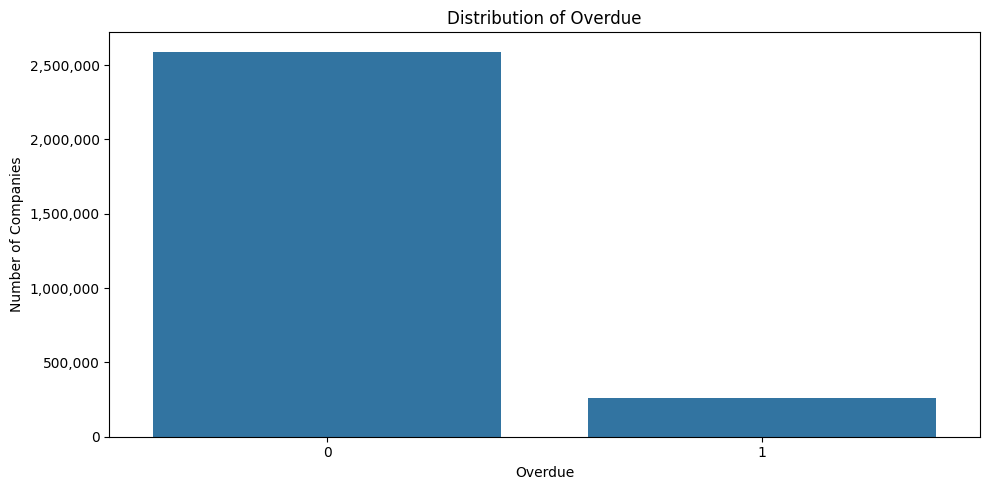

overdue,count,percentage
0,"2,590,974",90.97%
1,"257,282",9.03%


In [5]:
# Use the 'plot_numeric_distribution' helper function from 'utils.py' to visually display the balance of the overdue column.
plot_numeric_distribution(df, "overdue", tick_interval=1)

# Check the distribution of the overdue flag using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df, "overdue", hide_index=True)

The diagram above shows that the target variable has a large imbalance favouring *on-time* **(90.97%)** over *late* **(9.03%)**.

Logistic regression performs best on balanced data where the weight of each class is equal or near equal. As the Companies House data used in this project is severely imbalanced I will apply ***class-weighting*** and ***Synthetic Minority Oversampling Technique (SMOTE)*** when testing which model works best in the model pipeline.

- **Baseline:** The baseline model is trained on the original imbalanced dataset, where the majority class (*on‑time*) dominates. As a result, the logistic regression model becomes biased toward predicting the majority-class because *late-filers* receive very little representation during training.

- **Class‑weighting:** Class‑weighting increases the penalty for misclassifying the minority-class (*late*) so that these errors contribute more heavily to the model’s loss function. This ensures that the logistic regression model gives minority‑class examples proportionally greater influence during training, without altering the underlying data. This improves *recall* without altering the underlying data.

**SMOTE** creates synthetic examples of the minority-class (*late*) so that the number of observations matches the number of observations in the majority class (*on-time*). This will ensure that the logisitc regression model receives equal representation for both classes **during training**.

Model building is very resource intensive when datasets contain a large number of feature variables and categories as *one-hot endcoding* can expand the number of columns/variables in a dramatic way. Additionally, when there is a large number of observations like in the Companies House data I am using, which is **~2.85 million companies**. Therefore using a sample of the data for building and testing the model is the best option, which I will do next.

I use stratified sampling to ensure that the proportion of *late-filing* companies is not over or under represented in the newly created sample dataset.

## 3. Reduce the Dataset Size

**Stratified Sampling:**
- **Efficiencies:** The large size of the starting dataset **(~2.85m companies)** would be resource intensive for modelling therefore stratified sampling will speed up the processes without compromising the distribution late filings **(9.03%)**.
- **Proportions:** When splitting the data I stratify on the target variable counts to keep the **proportion** of *late* companies the same in both sets, and use a seed to ensure the results are replicable when running the process again using the same dataset. This also preserves the real-world distribution in the data to ensure it reflects the original population.

I will use a strafied sample size of **~25%** of the original population size.<br>
- Starting population = **2,848,256 companies**;
- **25%** sample data **712,064 companies**;
- **75%** discarded data = **2,136,192 companies**.

**NOTE:** The full sample should be used in a production model as maximum predictive accuracy is required and there is likely a much higher computational power available.

In [6]:
# Define the target variable, 'overdue' is the variable we want to predict (0 = on-time, 1 = late).
target = "overdue"

# Create the 25% stratified sample
df_sample, df_discard = train_test_split(
    df, 
    train_size = 0.25,        # train_size decides the proportion retained to create the sample dataset
    stratify = df[target],    # stratify defines which column should be used to stratify the data, note: y was defined as the target variable earlier
    random_state = 42         # random_state acts as a seed to ensure results are replicable when running the code again with the same data.
)

# Use the 'print_dataset_shape' helper function from 'utils.py' to display the number of rows and columns in the dataset.
print_dataset_shape(df)
print(f"Number of sample rows: {len(df_sample)}")
print(f"Number of discarded rows: {len(df_discard)}")

rows: 2,848,256
columns: 10
Number of sample rows: 712064
Number of discarded rows: 2136192


The figures above show that the starting population has now been reduced down to **25%** of it's original size in the sample, which will make the next stages more efficient. <br>
Next I confirm that the balance from the original population was not distorted in the sample.

In [7]:
# Check the distribution of the overdue flag using the 'value_counts_table' helper function from 'utils.py'. 
value_counts_table(df_sample, "overdue", hide_index=True)

overdue,count,percentage
0,"647,744",90.97%
1,"64,320",9.03%


This shows that we still have a **90.97%** (on-time) and **9.03%** (late) split, confirming that sampling did not distort the proportions. <br>
Instead of the original **~2.85m** rows I now have **~712 thousand rows**

## 4. Train Test Split

To ensure that all modelling decisions are free from *data leakage*, the sample dataset is divided into a **training** and a **testing** dataset. All modelling choices, including feature selection, scaling and endocing must be based solely on the **training** data so that the model doesn't indirectly learn from the test set.

Splitting the data **before** any transformation is essential becuase the test set must represent *unseen* future data. If the model or any preprocessing step is influenced by the test set, performance estimates become overly optimistic and the model becomes less generalisable. 

**Why the split must occur before scaling and encoding:**

- **Scaling (Standardisation):** The mean and standard deviation used in *StandardScaler* would be computed on the entire dataset, these statistics would then be applied to the training data, which would leak information from the test set into the training process.
- **One-hot Encoding:** Performing *one-hot encoding* before splitting also introduces leakage risks. If a categorical variable has a rare category that only exists in the test set then doing *one-hot encoding* before the splitting could introduce a dummy column for that category in the training data, even though the training data never contained it. Conversely, the model could learn about categories that only appear in the test set, which it should not know exist during training. This artificailly stabalises the feature spare and gives the model information it would not have in a realy deployment situation. By fitting the encoder one the training data only, the model learns categories that genuinely exist in the training distribution. Any unseen categories in the test set are safely handled using handle_unknown="ignore".

Splitting the data into testing and training data should should be done with care to ensure that there is a representation of *on-time* and *late* in both the datasets, therefore I will stratify on the *target* variable *overdue*.

For this spltitting I will use **80%** of the data as the **training** dataset and **20%** as the **testing** dataset so that the model has a larger proportion of data to train on and a smaller proportion to test on. Having more data to train on gives the model more information to work with and increases the likelihood of it performing well on the test dataset.
<br> <br>

Before conducting the splitting, I separate out the predictors (x) and the target variable (y), so that model learns from the predictor variables only, and not from the target variable (what it is trying to predict). Also because *scikit-learn* expects **2** separate inputs *x* which is a *2-dimensional array* of predictor variables and *y* which is a *1-dimensional array* of the target variable. 

In [8]:
x = df_sample.drop(columns=[target])     # define x which contains all predictor/feature variables.
y = df_sample[target]                    # define y which contains only the target variable

In [9]:
# Split the data into training and testing datasets
# take the output of train_test_split (which returns 4 items - x_train, x_test, y_train, y_test)
# and assign each one to a clearly named variable so the model knows
# which data to learn from (train) and which data to be tested on (test)
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,          # hold aside 20% for the test data leaving 80% for the training data unbiased model evaluation
    stratify = y,             # use stratified sampling to preserve class proportions in train/test split to avoid skew
    random_state = 42         # fix the random seed so results are reproducible across runs
)

Now I check the distribution *target* variable *overdue* for the train and test data.

In [10]:
print(f"Train: {y_train.value_counts(normalize=True)}") # check class balance in the training set (proportion of 0 vs 1)
print(f"Train number of rows: {len(y_train)} \n")       # confirm training sample size after the split
print(f"Test: {y_test.value_counts(normalize=True)}")   # check class balance in the test set to ensure stratify worked
print(f"Test number of rows: {len(y_test)}")           # confirm test sample size (should be 20% of total)

Train: overdue
0    0.909671
1    0.090329
Name: proportion, dtype: float64
Train number of rows: 569651 

Test: overdue
0    0.909671
1    0.090329
Name: proportion, dtype: float64
Test number of rows: 142413


This demonstrates that both the *test* and *train* data share the same proportionality of *on-time* to *late* as the original population, and together the number of rows adds up to the size of the sample dataset from earlier meaning that there was no bias introduced in either the sampling of the original dataset or in the splitting of the sample in the test-train split of the sample. **train (569,651) + test (142,413) = sample (712,064)** <br><br>
I can therefore be confident in the training data and testing data and consider it as being representative of the original population in terms of the *overdue* distribution, but must remember that the distribution of each feature variable in the test/train data and the sample data may not represent the same distribution as the feature variables in the original population.

## 5. Investigating Impact of Variables.

This section evaluates whether each feature contributes meaningful predictive power to the logistic regression model or whether it introduces unnecessary noise and should therefore be removed. 

To determine whether each variables displays enough variation to be a meaningful predictor of late filing behaviour, I will examine the *late filing rate* for each category within each feature variable. If all categories within a variable display identical or near-identical *late-filing rates*, then the variable cannot distinguish between companies that file *late* and those that file *on-time*. Where this happens, the variable would add noise rather than predictive value and will be removed from the model.

This assessment will inform which variables are retained and how each one is treated within the *'preprocessor'* function that I will create later. Variables showing strong differences in *late-filing* rates across categories will be kept, while those showing minimal or no variation will be excluded or transformed.

For the purposes of logistic regression **binary columns will be treated as categorical**, because although they are endocded as **0/1**, they represent two distinct groups (*late* vs *on-time*) rather than continuous numeric values, therefore all variables are categorical and will undergo the same type of examination.

This analysis is used to inform the decisions on feature selection and manipulation, it is only carried out on the **training dataset**. Performing *late-rate* calculations on the full dataset would leak information from the test set into this decison making process which would artificially improve the performance of the model and undermine the evaluation conducted here.

In [11]:
# Get list of category_cols and list of numeric columns to prove they are categorical.
categorical_cols = x.select_dtypes(include=["category", "int8"]).columns.tolist()
numeric_cols = x.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Print them for observations
print(f"Categorical variables: {categorical_cols}")
print(f"Numeric variables: {numeric_cols}")

Categorical variables: ['company_category', 'accounts_group', 'registered_country', 'industry', 'company_age_when_acc_due', 'psc_count', 'has_corporate_psc', 'has_foreign_psc', 'recent_psc_change']
Numeric variables: []


The training dataset is currently housed in *x_train* and *y_train* from the *train_test_split()* process earlier. To conduct the *late-rate* analysis and use the *plot_late_rate_by_category()* helper function from *visualisations.py* df_train must be created, which is a combination of the *x_train feature* variables and the *y_train target* variable.

In [12]:
# Create a df_train dataset by using a copy of the x_train dataset and joining the target variable
# back in from the y_train data, these were created in the test-train split above.
df_train = x_train.copy()
df_train[target] = y_train

# Check the distribution of the overdue flag using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df_train, "overdue", hide_index=True)

overdue,count,percentage
0,"518,195",90.97%
1,"51,456",9.03%


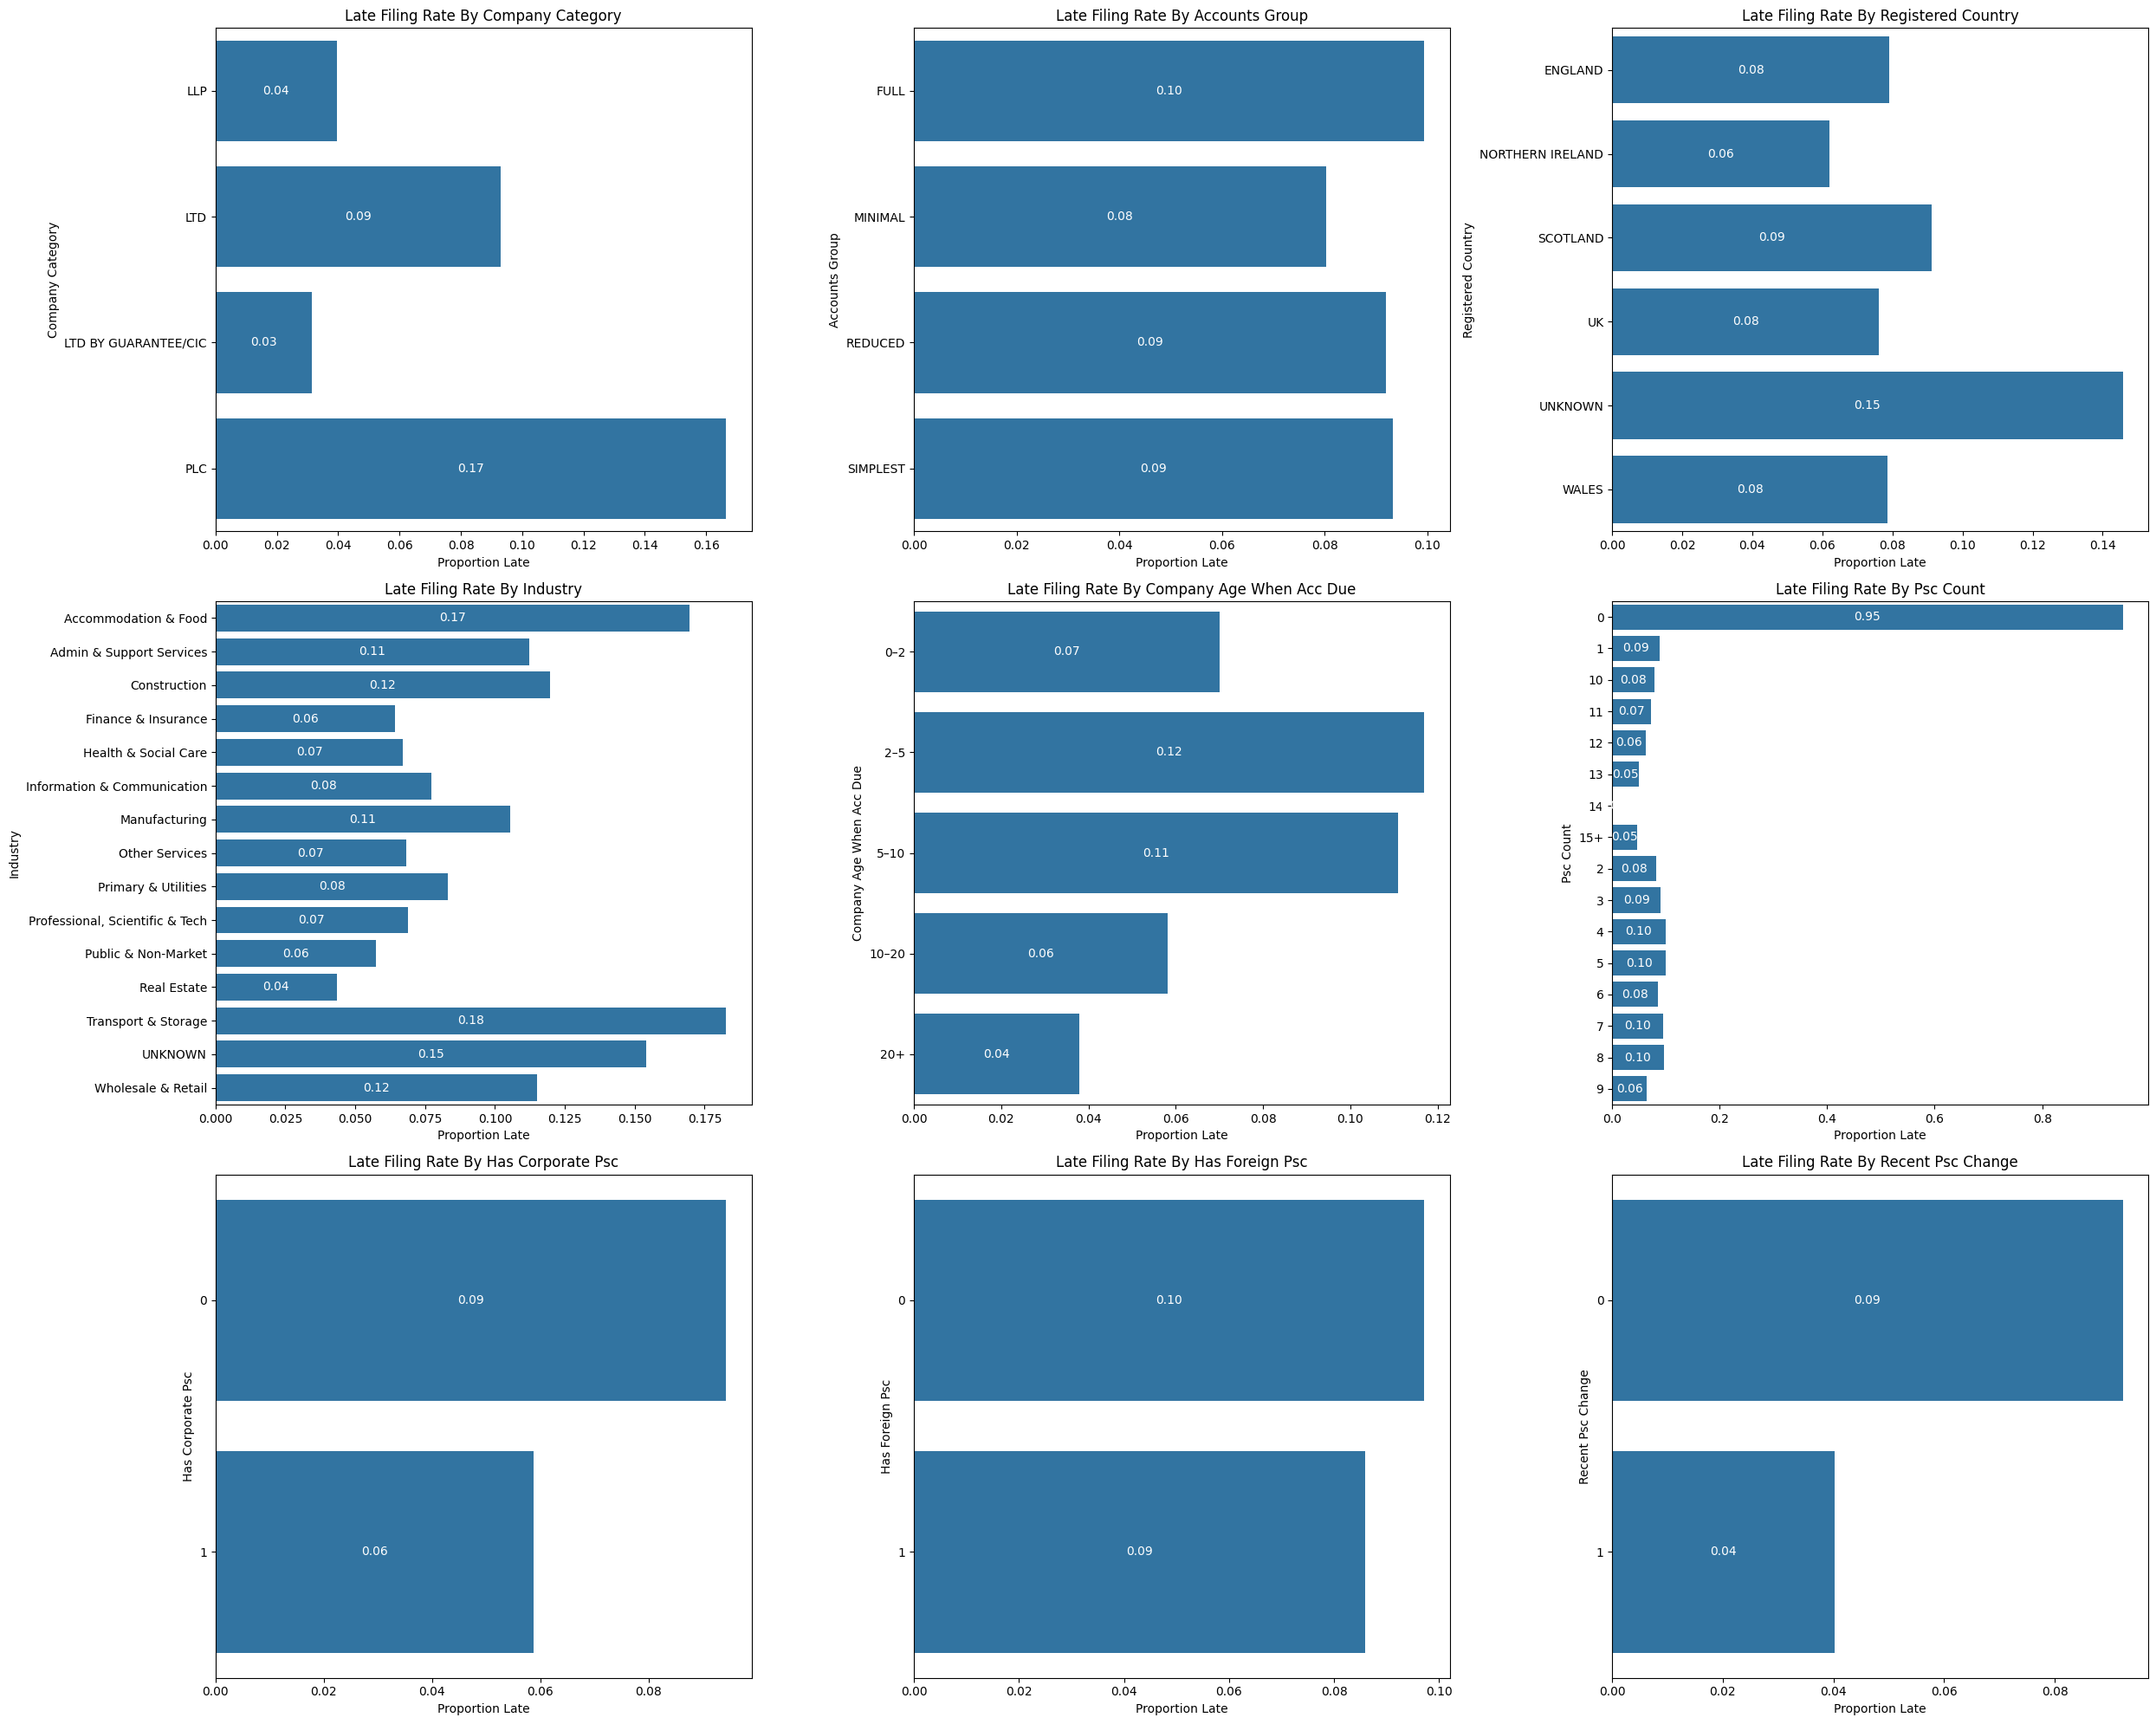

In [13]:
# Use the 'plot_late_rate_by_category_grid' helper function from 'visualisations.py'
# to visualise the late-rate for each categorical variable.
plot_late_rate_by_category_grid(df_train, categorical_cols, ncols=3, figsize=(25,20))

The *late-rate* by *psc_count* is difficult to intepret so will be extracted below.

In [14]:
summary = (                                              # Create summary dataframe
            df.groupby("psc_count", observed=True)["overdue"]           # Group by the selected column
            .mean()                                              # Compute late‑filing rate per category
            .reset_index()                                       # Reset the index to start at zero
            .sort_values("overdue", ascending=False)            # Sort categories by late rate
        )
print(f"Largest Late Rate\n{summary.head(2)} \n")
print(f"Smallest Late Rate \n{summary.tail(2)}")

Largest Late Rate
   psc_count   overdue
0          0  0.955476
11         5  0.101613 

Smallest Late Rate 
  psc_count   overdue
7       15+  0.029520
5        13  0.026786


| **Variable** | **Lowest Rate** | **Highest Rate** | **Range (%age points)** | **Risk Ratio (High / Low)** | **Interpretation** | **Decision** |
|-----|-----|-----|-----|-----|-----|-----|
| **Company Category** | 0.03 (LTD BY GUARANTEE/CIC) <br><br> Approx. 1/3 of the population baseline (9.03%) | 0.17 (PLC) <br><br> Almost 89% higher than population baseline (0.0903). | <center> 14pp </center> | <center> 0.17/0.03 = 5.67 </center> PLC companies are **almost 6 times more likely** to file late than LTD BY GUARANTEE/CIC companies. | Very strong separation = High predictive signal. | **Retain** the variable as it stands. It demonstrates meaningful predictive power. |
| **Accounts Group:** | 0.08 (MINIMAL) <br><br> Close to the population baseline. | 0.10 (REDUCED and FULL) <br><br> Close to the population baseline. <br><br> This is 2 out of the 4 categories.  | <center> 2pp </center> | <center> 0.10/0.08 = 1.25 </center> The difference between the groups is only 2 percentage points, giving a weak risk ratio of 1.25. | Very weak separation = Limited predictive value <br><br> **All groups approx. 8-10% file accounts late.** *One-hot encoding would simply add noise.* | **Remove** the variable as it offers **no discriminatory power.** |
| **Registered Country:** | 0.06 (NORTHERN IRELAND) <br><br> 2/3 of population baseline. | 0.15 (UNKNOWN) <br><br> 66% larger than population baseline. | <center> 9pp </center> | <center> 0.15/0.06 = 2.5 </center> Registered country = UNKNOWN are **2.5 times more likely** to file late NORTHERN IRELEAND. <br><br> UK nations only differ slightly (6-9%) but UNKNOWN offers meaningul variation. | Moderate separation = Useful predictor <br><br> The predictive signal comes almost entirely from the **UNKNOWN** category; the **UK** nations show minimal variation. | **Retain** variable **after collapsing into *UNKNOWN* and *KNOWN UK*** as it offers meaningful predictive power. |
| **Industry** | 0.04 (Real Estate) <br><br> 43% of the population baseline. | 0.18 (Transport & Storage) <br><br> Almost double the population baseline. | <center> 14pp </center> | <center> 0.18/0.04 = 4.5 </center> Those in the transport and storage industry are **4.5 times more likely** to file late than those in the real estate industry. | Very strong separation = Highly predictive. | **Retain** the variable as it stands.  It demonstrates meaningful predictive power. <br><br> *Note: Further work beyond this analysis could be to reduce the number of industry categories even further.* | 
| **Company Age When Accounts Due** | 0.04 (20+) <br><br> 43% of the population baseline. | 0.12 (2-5 years) <br><br> 1.33 x population basleine. | <center> 8pp </center> | <center> 0.12/0.04 = 3.0 </center> Younger companies (2-5 years) are **3 times more likely** to file late than older companies (20+). | Strong separation = Good predictive value. | **Retain** the variable as it stands. It demonstrates meaningful predictive power. |
| **PSC Count** | 0.03 (13 PSCs) <br><br> 33* of the population baseline. | 0.96 (0 PSCs) <br><br> ~10.6 times higher than the population baseline | <cemter> 93pp </center> | <center> 0.96/0.03 = 32 <br> 0.96/0.10 = 9.6 </center> Companies with no PSC are **between 10 and 32 times more likely** to file late than those with any number of PSCs | Very strong separation = Useful predictor <br><br> The predictive signal comes almost entirely from the **Zero PSCs** category compared to **any PSCs**. | **Retain** variable **after collapsing into a binary variable *any_psc_count*** as it offers meaningful predictive power and this will remove noise for *one-hot encoding*. |
| **Has Corporate PSC** | 0.06 (Yes) <br><br> 66% of the population baseline. | 0.09 (No) <br><br> Almost equal to the population baseline. | <center> 3pp </center> | <center> 0.09/0.06 = 1.5 </center> Companies without a coporate PSC have a slightly higher late-filing rate (3 percentage points), equivalent to **1.5x the relatvie risk** than those with a corporate PSC. | Weak to Moderate separation = Some predictive value but not lots. | **Retain** the variable - It is **low cost** to retain this **binary variable**, and it offers some predictive power, albeit not strong. |
| **Has Foreign PSC** | 0.09 (Yes) <br><br> Almost equal to population baseline. | 0.10 (No) <br><br> Only slightly larger than the population baseline. | <center> 1pp </center> | <center> 0.1/0.09 = 1.11 </center> Companies without a foreign PSC are **only 11% more likely** to file late than those who have a foreign PSC. | Very weak separation = poor predictive power. | **Remove** variable as it has **negligible predictive power**, acting similar to the base population. |
| **Recent PSC Change** | 0.04 (Yes) <br><br> 43% of the population baseline. | 0.09 (No) <br><br> Almost equal to the population baseline. | <center> 5pp </center> | <center> 0.09/0.04 = 2.25 </center> Companies without a recent PSC change are **twice a likely to file late** than those with a recent PSC change. | Moderate separateion = potential prediticve power. | **Retain** the variable as it stands. It displays meaningful predictive power. |

**Preprocessing Steps:**
- Remove *accounts_group*.
- Collapse *registered_country* into ***UNKNOWN and KNOWN_UK***.
- Collapse *psc_count* into the binary variable **any_psc_count**.
- Remove *has_foreign_psc*.


## 6. Preprocessing steps.

Next I will conduct the preprocessing steps discussed above on the df_train and evaluate the effects.

### Registered Country

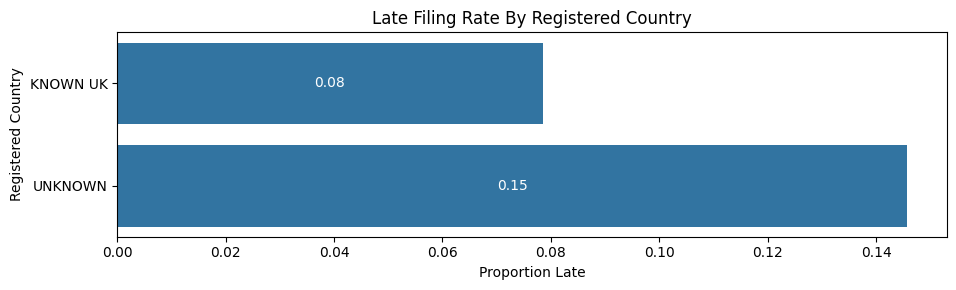

In [15]:
# Replace each appearance of each known country with 'KNOWN UK'
registered_country_map = {
    "SCOTLAND": "KNOWN UK",
    "ENGLAND": "KNOWN UK",
    "WALES": "KNOWN UK",
    "NORTHERN IRELAND": "KNOWN UK",
    "UK": "KNOWN UK"
    }

# Replace the registered country with the new registered country using the 'map_categories' helper function from 'utils.py'
df_train["registered_country"] = map_categories(df_train["registered_country"], mapping=registered_country_map);

# Plot the late filing rate by 'registered_country' using the 'plot_late_rate_by_category' helper function from 'visualisations.py'.
plot_late_rate_by_category_grid(df_train, ["registered_country"], target_col="overdue", figsize=(35, 3))

The above chart clearly demonstrates why retaining this feature was justified. It preserves the predictive signal while reducing the sparsity of the *one-hot encoded* categories of *KNOWN UK*, improving model stability. Companies in the *UNKNOWN* category are almost **twice as likely** to file late compared with companies where the registered country is *KNOWN UK* (**0.15/0.08 = 1.875**). They are around **66% more likely** to file late than the population baseline (**9.03%**). This confirms that the *UNKNOWN* category behaves as a distinct risk group and that *registered_country* carries meaningful predictive value. For this reason, the feature is retained. The method used above must be replicated in the model preprocessor created later.

### PSC Count

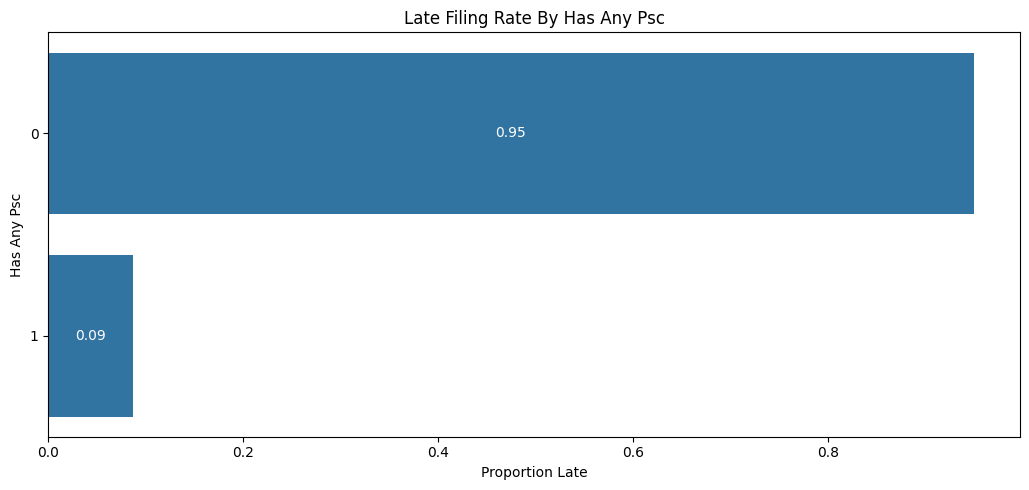

In [16]:
# Flag where a company has no PSC as 0 and 1 where a company has any PSCs.
df_train["has_any_psc"] = (df_train["psc_count"] != "0").astype("int8")

# Plot the late filing rate by 'has_any_psc' using the 'plot_late_rate_by_category_grid' helper function from 'visualisations.py'.
plot_late_rate_by_category_grid(df_train, ["has_any_psc"], target_col="overdue", figsize=(40, 5))

In [17]:
# Check the distribution of the overdue flag using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df_train, "has_any_psc", hide_index=True)

has_any_psc,count,percentage
1,"567,445",99.61%
0,"2,206",0.39%


**95%** of companies without a PSC file late, vs only **9%** of companies with any number of **PSCs**

**~2,206 companies** out of **567,445** have no PSC recorded (**~0.39%** of the population). This is a very small subgroup, however these companies exhibit an exceptionally high *late-filing rate* of **~96%**, compared with **~9%** for companies with at least one PSC. This represents a risk-ratio of around **~10.667 (96/9)**, meaning that where a company has no PSC listed it is **10.67** times more likely to file *late* than a company with any number of PSCs. This is an extremely large risk ratio, which indicates a very strong association with late-filing. Therefore, the engineered binary variable *has_any_psc* identifies a rare but extremely *high-risk* segment of the population and provides a clear interpretable signal for the logistic regression model. This variable will be retained and the original *psc_count* column will be removed.

Two other columns will also be removed here, as discussed earlier *accounts_group* and *has_foreign_psc* do not offer enough predictive signalling to be retained.

In [18]:
# Remove psc_count column as it is no longer needed, using the 'drop_columns_and_report' helper function from 'utils.py'
# Also remove 'accounts_group' and 'has_foreign_psc'.
df_train = drop_columns_and_report(df_train, columns=["psc_count", "accounts_group", "has_foreign_psc"])
df_train.head()

rows: 569,651
columns: 8


,company_category,registered_country,industry,company_age_when_acc_due,has_corporate_psc,recent_psc_change,overdue,has_any_psc
2450338,LTD,KNOWN UK,Other Services,10–20,0,0,1,1
1339951,LTD BY GUARANTEE/CIC,UNKNOWN,Health & Social Care,20+,0,0,0,1
354106,LTD,KNOWN UK,Admin & Support Services,10–20,0,0,0,1
773643,LTD,KNOWN UK,Health & Social Care,2–5,0,0,1,1
421363,LTD,KNOWN UK,Real Estate,5–10,0,0,0,1


The dataset has been reduced down to **7** predictive features and **1** target variable.

## 7. Multicollinearity

After deciding upon and cleaning the feature variables I will now ensure there is no multicollinearity present, if any is present I will decide which to variables to retain, which to remove or justify the retention of them both/all.

All predictors are now either binary or categorical. Since binary variables behave more like categorical variables, and there are no continuous numeric variables left, Cramer's V will be used as it measures the association between any pair of categorical variables, including binary variables.

Cramer’s V is a statistical measure (ranging from **0** to **1**) that described how strongly two categorical/binary variables are associated. It is derived from the *chi‑square* statistic and standardised so it is not inflated by large sample sizes.

This next function computes pairwise Cramer's V for all categorical/binary columns and plots a heatmap showing categorical associations. This helps identify redundant or highly related features.

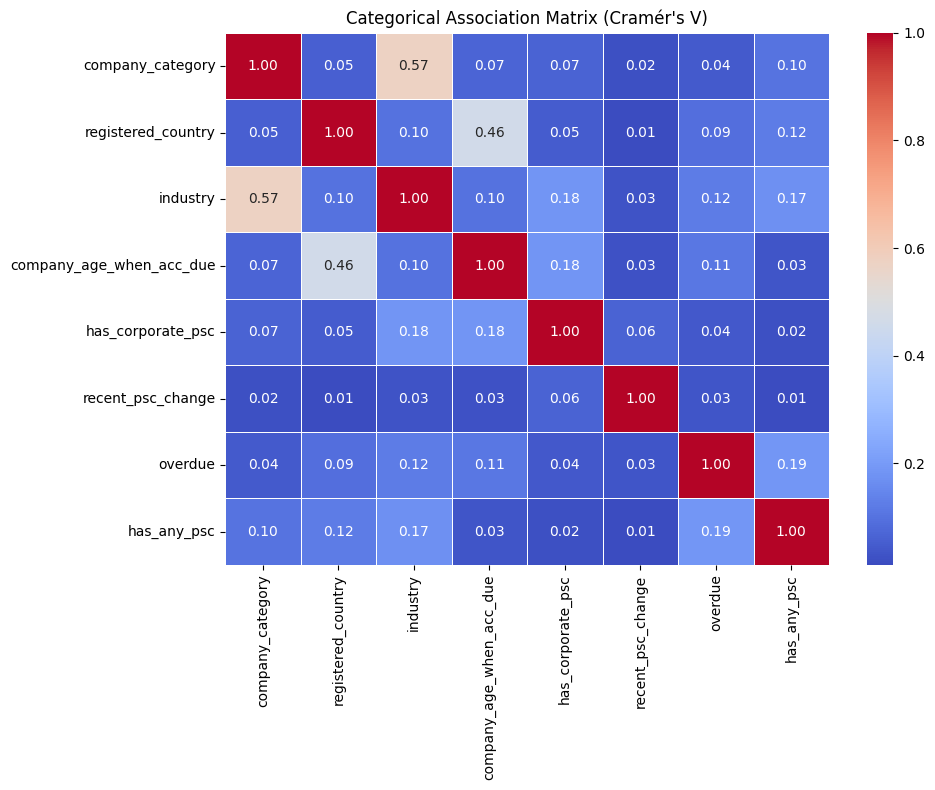

In [19]:
# Use the 'plot_categorical_association' helper function from 'visualisations.py' to plot a correlation matrix.
plot_categorical_association(df_train);

This matrix shows the following:
- There are no associations above **0.60**
- The strongest relationship is *company_category* and *industry* as they have Cramer's V **> 50** at **0.57**, this is not strong enough to consider dropping either variable.
- *registered_country* and *company_age_when_acc_due* are second strongest at **0.46**, making them somewhat strongly associated as they have Cramer's V between **0.3-0.5**, also not high enough to consider dropping either.
- All other variables have low-very low association with each other, displayed by the blue colouring of the squares and the low numbers.
- The target shows low to very low associations with the feature variables, but weak Cramer's V does not indicate weak predictive power, as discussed above, all variables provide meaningful predictive power.

**Decision:** No more variables will be removed from the dataset, all can be taken through to the logisitc regression model building. This dataset is ready for one-hot encoding and logistic regression modelling.

I will define the logistic regression function here and apply it to both df_train and df_test.

In [20]:
# Create the feature engineering defined function that will be used for the logistic regression model
# Uses the same processes as conducted above.
def log_reg_feature_engineering(df):
    df = df.copy()

    # Collapse registered_country
    registered_country_map = {
        "SCOTLAND": "KNOWN UK",
        "ENGLAND": "KNOWN UK",
        "WALES": "KNOWN UK",
        "NORTHERN IRELAND": "KNOWN UK",
        "UK": "KNOWN UK"
    }
    df["registered_country"] = map_categories(df["registered_country"], mapping=registered_country_map)

    # PSC engineering
    df["has_any_psc"] = (df["psc_count"] != "0").astype("int8")

    # Drop removed columns
    df = drop_columns_and_report(
        df,
        columns=["psc_count", "accounts_group", "has_foreign_psc"]
    )

    return df

Now I apply the feature engineering function to *x_train* and *x_test* to bring them both into line using the same processes from section ***Preprocessing Steps***

In [21]:
# Apply the feature engineering function to x_train and x_test
print(f"x_train:")
x_train = log_reg_feature_engineering(x_train)
print(f"\n x_test:")
x_test  = log_reg_feature_engineering(x_test)

x_train:
rows: 569,651
columns: 7

 x_test:
rows: 142,413
columns: 7


##### Feature/Predictor Variables Retained/Removed (with justification):
- **company_category:** After mapping into fewer, legally meaningful groupings, the categories were well-represented and showed sufficient variability in late-filing behaviour. Company legal form is a fundamental structural characteristic and a defensible predictor of administrative behaviour.
- **company_age_when_acc_due:** Binning the raw ages into meaningful real-world age bandings revealed clear differences in late-filing rates. Younger companies showed higher risk, while older firms were more compliant. The binned version proved to be appropriate for logistic regression.
- <span style="color: red;">**accounts_category:** Although filing obligations are legally relevant, the *late-filing rates* across all categories showed minimal variation (**8-10%**). The feature threfore provided no discriminatory power and was removed.</span>
- **industry:** After reducing the number of categories down to a manageable quantity, *industry* showed strong variability in *late-filing rates*. Industry may affect behaviours in many ways, for example the seasonality of one category, or the oversight by solicitors and accountants etc. The industrial context is also operationally important and could directly inform which team within Companies House would conduct any investigative/supportive activity, and what type of activity that may be. When comparing the *late-filing rate* there was enough variability in the data to be considered predictive.
- **registered_country:** After engineering down to **UNKNOWN** and **KNOWN UK** due to data quality issues, the **UNKNOWN** category showed distinct late-filing behaviour, potentially reflecting different regulatory environments and more complex administrative patterns. This feature retained predictive value.
- **has_any_psc:** This variable was engineered from the original *psc_count* field to distinguish companies with at least one identifiable PSC from those with none. Companies with no PSCs form a very small but behaviourally distinct group, exhibiting extremely high *late‑filing rates*. The absence of any PSC may indicate unusual organisational structure, which can be associated with administrative risk. This engineered binary variable therefore captures a clear and interpretable behavioural signal and is retained, <span style="color: red;">while the original **psc_count** variable is removed.</span>
- **has_corporate_psc:** This variable identifies whether a company’s controlling mind is a corporate entity rather than an individual. Companies without a corporate PSC show noticeably higher *late‑filing rates*, suggesting that individual‑controlled firms may face different governance pressures or administrative practices. The variable is clean, well‑represented across the population, and reflects a meaningful structural characteristic of company ownership. It is therefore retained.
- <span style="color: red;">**has_foreign_psc:** This feature captures whether any PSC is registered outside the *UK*. This feature did not show enough predictive value with only **11%** increase in late-filing when a company did not have any foreign PSC vs having any foreign PSC. Other variables were stronger, therefore this one was dropped.</span>
- **recent_psc_change:** This variable indicates whether a company has undergone a recent change in its PSC structure. Companies with a recent PSC change display very different filing behaviours, potentially reflecting organisational transitions, governance adjustments, or administrative disruption. Despite being less common, the behavioural separation between the two groups is strong, and the feature is clean and interpretable. It is therefore retained.
- **overdue:** This is the binary target variable, with **90.97%** not overdue and **9.03%** overdue. Although imbalanced, the minority class is still well‑represented in absolute terms (**257k** overdue cases). The imbalance reflects real‑world behaviour, where most companies comply and file *on-time*. Retaining the natural distribution preserves the real‑world context of the problem and allows the model to learn realistic risk patterns.

## 8. Preprocessing (Encoding categorical variables and Scaling numeric variables)
- Logistic regression requires numeric input, it cannot work directly with text categories, *OneHotEncoder()* turns variables containing categorical data into multiple binary columns which can then be used in the logistic regression model.  **NOTE:** Using *drop="first"* avoids multicollinearity as otherwise all of the *one-hot encoded* columns together will be able to directly predict the original column that was encoded.
- *StandardScaler* ensures each numerical feature has a mean of **0** and a standard deviation of **1**. This prevents features with larger numeric ranges from dominating the model training in logistic regression, improving model stability.

Checking which columns are categorical and which are numeric and then use *OneHotEncoder()* on the list of categorical features and *StandardScaler()* on the list of numeric features.

Binary variables should go through the *OneHotEncoder()* not the *StandardScaler()* as they are considered categorical. *drop="first"* ensures that the process doesn't create **2** columns for the binary variables.

In [22]:
# Identify categorical and numeric columns.
categorical_cols = x_train.select_dtypes(include=["category", "int8"]).columns.tolist()
numeric_cols = x_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Display the list of columns for checking
print(f"Categorical Columns: {categorical_cols}")
print(f"Numerical Columns:   {numeric_cols}")

Categorical Columns: ['company_category', 'registered_country', 'industry', 'company_age_when_acc_due', 'has_corporate_psc', 'recent_psc_change', 'has_any_psc']
Numerical Columns:   []


All of the columns have remained categorical columns, therefore only the *OneHotEndocer()* will be required. I will leave the *StandardScaler()* line in the code, just to demonstrate what it would look like for a mixed variable type dataset. It does nothing when the list is empty, so it provides no harm to leave this in the script.

In [23]:
# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),                                         # Apply standard scaler to numerical variables.
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)  # Apply OneHotEncoder to categorical variables.
    ]
)

## 9. Model Building
Here I will build **3** model pipelines to be used on the data for training a model. I will compare the outcomes of all three to identify which is best for our data.

##### A - Baseline Model
The pipeline will keep the preprocessing and modelling together, to ensure that the same steps are applied consistently during training and testing, and it avoids having to manually do the transformations twice.

In [24]:
pipeline_baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),                                # apply scaling + one‑hot encoding to all features before modelling
        ("model", LogisticRegression(max_iter=1000, random_state=42))  # fit a baseline logistic regression; higher max_iter ensures convergence
    ]                                                                  # random state ensures reproducibility
)

pipeline_baseline.fit(x_train, y_train)                     # fit the full pipeline on the training data (preprocessing + model training in one step)
y_pred_base = pipeline_baseline.predict(x_test)             # generate class predictions (0/1) for evaluation
y_prob_base = pipeline_baseline.predict_proba(x_test)[:, 1] # extract predicted probability of being late (class 1) for metrics like AUC and thresholding

##### B - Class Weight Model
This model penalises misclassification of late filings, and adjusts its learning without changing the underlying data.

In [25]:
pipeline_weighted = Pipeline(
    steps=[
        ("preprocessor", preprocessor),      # apply scaling + one‑hot encoding before modelling (same as baseline)
        ("model", LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)) 
        # use class_weight='balanced' to up‑weight the minority class (late) during training
        # this adjusts the loss function so late filers (class 1) have more influence
    ]
)

pipeline_weighted.fit(x_train, y_train)                     # fit the full pipeline on the training data (preprocessing + weighted logistic regression)
y_pred_weighted = pipeline_weighted.predict(x_test)         # generate class predictions (0/1) for evaluation
y_prob_weighted = pipeline_weighted.predict_proba(x_test)[:, 1] # extract predicted probability of being late (class 1) for AUC and threshold analysis

##### C - SMOTE Model
This pipeline creates sythetic examples of late filing companies (the minority class of the population) which will be applied to the training data via a pipeline to avoid data leakage.

In [26]:
pipeline_smote = Pipeline(
    steps=[
        ("preprocessor", preprocessor),                                # apply scaling + one‑hot encoding before oversampling
        ("smote", SMOTE(random_state=42)),                             # oversample the minority class *after* preprocessing but *before* model fitting
                                                                       # creates synthetic minority examples so the model sees a balanced training set
        ("model", LogisticRegression(max_iter=1000, random_state=42))  # fit logistic regression on the SMOTE‑balanced data
    ]
)


pipeline_smote.fit(x_train, y_train)                      # fit the full pipeline on the training data (preprocessing -> SMOTE -> model training)
y_pred_smote = pipeline_smote.predict(x_test)             # generate class predictions (0/1) for evaluation
y_prob_smote = pipeline_smote.predict_proba(x_test)[:, 1] # extract predicted probability of being late (class 1) for AUC and threshold analysis

## 10. Model Evaluation Table
Now I create a table allowing me to evaluate and compare all of the models against each other.
Here I focus on Recall and Precision.
- **Recall:** Detection of *late-filers*
- **Precision:** False positives

In [27]:
# Create a comparison table of the results from the 3 models built in the previous steps
results = pd.DataFrame({
    'Model': ['Baseline', 'Class Weight', 'SMOTE'],  # Column labels for each model so results are easy to compare

    # Values to enter in each column
    'Precision': [                                   # precision = proportion of predicted late filers that were actually late
        precision_score(y_test, y_pred_base),        # precision score for the baseline model
        precision_score(y_test, y_pred_weighted),    # precision score for the class-weighted model
        precision_score(y_test, y_pred_smote)        # precision score for the SMOTE model
    ],

    'Recall': [                                      # recall = proportion of actual late filers the model successfully identified
        recall_score(y_test, y_pred_base),           # recall score for the baseline model
        recall_score(y_test, y_pred_weighted),       # recall score for the class-weighted model
        recall_score(y_test, y_pred_smote)           # recall score for the SMOTE model
    ],

    'F1 Score': [                                    # F1 = harmonic mean of precision and recall (balances both)
        f1_score(y_test, y_pred_base),               # F1 score for the baseline model
        f1_score(y_test, y_pred_weighted),           # F1 score for the class-weighted model
        f1_score(y_test, y_pred_smote)               # F1 score for the SMOTE model
    ],

    'ROC_AUC': [                                     # ROC‑AUC = ranking ability across all thresholds (uses predicted probabilities)
        roc_auc_score(y_test, y_prob_base),          # ROC-AUC for the baseline model
        roc_auc_score(y_test, y_prob_weighted),      # ROC-AUC for the class-weighted model
        roc_auc_score(y_test, y_prob_smote)          # ROC-AUC for the SMOTE model
    ]
})
# display the comparison table for all three models
results

,Model,Precision,Recall,F1 Score,ROC_AUC
0,Baseline,0.857576,0.065998,0.122564,0.717385
1,Class Weight,0.155726,0.657805,0.251834,0.718495
2,SMOTE,0.155559,0.659748,0.251758,0.718230


To gain a visual representation of the numbers in the model evaluation table I will generate a clustered column chart, to compare the **3** models. This will shows any trade-offs between the **3** models.

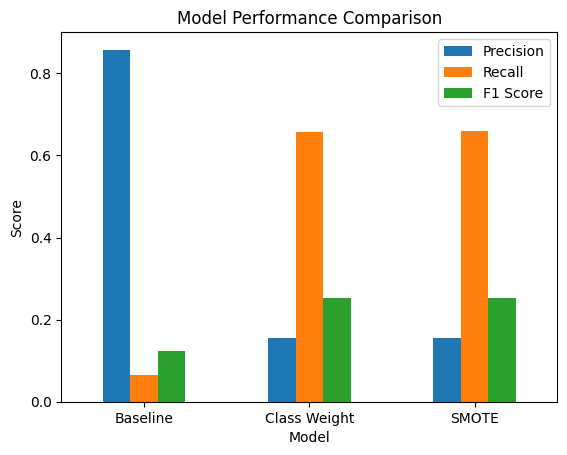

In [28]:
comparison_chart = results.set_index('Model')                           # set 'Model' as the index so metrics line up correctly for plotting
comparison_chart[['Precision', 'Recall', 'F1 Score']].plot(kind='bar')  # select Precision, Recall, and F1 Score for visual comparison
                                                                        # create a grouped bar chart to compare model performance across these metrics

plt.title("Model Performance Comparison")                               # add title for clarity
plt.ylabel("Score")                                                     # add y-axis label for clarity
plt.xticks(rotation=0)                                                  # keep model names horizontal for readability
plt.show()                                                              # render the chart

The *class-weight* and *SMOTE* models look almost identical here, therefore the numbers need to be closely examined to assess which one is best.

**Precision** measures the proportion of companies predicted to file *late* that actually did file late. A model with higher precision produces **fewer false positives**, meaning fewer compliant companies are incorrectly flagged as *non-compliant* or *late*.

**Recall** measures the proportion of all *late-filing* companies that the model successfully identified (predicted would file *late*). A model with high recall produces **fewer false negatives**, meaning it misses fewer genuinely *late-filers*. The trade-off is that recall often increases by accepting more false positives.

**F1** is a balance between *precision* and *recall*. It rewards models that maintain a reasonable balance between the two and penalises models that perform well on one metric but poorly on the other. It only scores low in models where both precision and recall are good.

For this project **recall is the most important metric** of the **3**. Missing out on identifying *late filers* may represent a regulatory failure, whereas incorrectly flagging and *on-time* company may create extra administrative work. The operational question is whether the organisation prefers to minimise missed late filers (high recall) or minimise unnecessary investigations (high precision). In a regulatory contect, recall typically carries more weight.

**Interpretation of the Results:**
- **Precision** is much higher in the *baseline model* than the other two models, but this comes at the cost of **extremely low recall**. The *baseline model* almost never identifies late filers, so its high precision is misleading as it is not predicting *late* very often.

- **Recall** increases dramatically in both the *class-weight* and *SMOTE* models. This means they identify far more *late-filing* companies. However, this improvement comes with a **large drop in precision**, meaning a larger proportion of the companies the models flag as *late* are actually *on-time*.

- The **F1 Score** is higher in the *class-weight* and *SMOTE* models than in the *baseline model*. This indicates that the rebalanced models achieve a better overall balance between precision and recall than the *baseline model*.

In practical terms, rebalancing the sample population using both *SMOTE* and *class-weighting* produces models that are **far more effective at identifying late-filing companies**, even though they generate more false positives. For a regulatory body such as Companies House, this trade-off is acceptable where the priority may be to detect as many risky companies as possible, even if it means reviewing some compliant companies along the way that were incorrectly identified as *late*.

Both rebalanced models outperform the baseline in the metric that matters mose for this use case, so **class-weighting or SMOTE is the better modelling choice**.

Let's look at the ROC Curve to further assess.

## 11. Receiver Operating Characteristic (ROC) Curve
Now I plot the ROC Curve to evaluate the discriminatory ability of the models.
**Note:** A higher curve = a better model

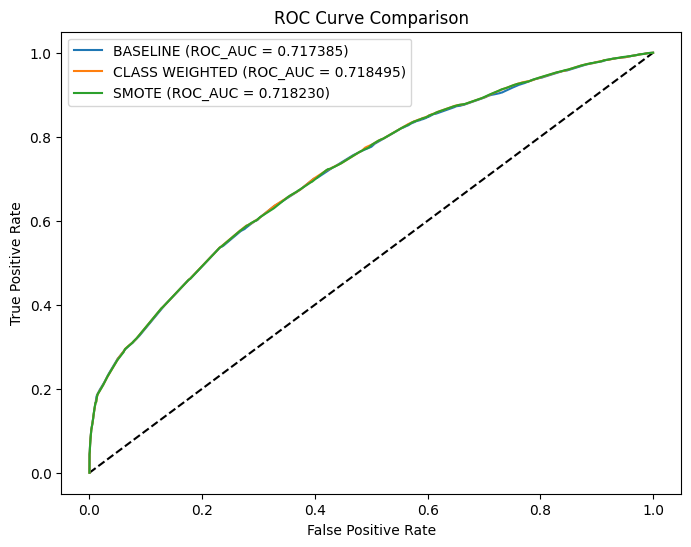

,Model,Precision,Recall,F1 Score,ROC_AUC
0,Baseline,0.857576,0.065998,0.122564,0.717385
1,Class Weight,0.155726,0.657805,0.251834,0.718495
2,SMOTE,0.155559,0.659748,0.251758,0.718230


In [29]:
# compute FPR (False Positive Rate) and TPR (True Positive Rate) for each model using predicted probabilities
# these curves show how each model trades off true positives vs false positives
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)             # fpr and tpr for baseline model
fpr_weighted, tpr_weighted, _ = roc_curve(y_test, y_prob_weighted) # fpr and tpr for class-weighted model
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)          # fpr and tpr for SMOTE model

plt.figure(figsize=(8,6))        # create plotting area
plt.plot([0,1], [0,1], 'k--')    # add diagonal reference line representing a random classifier

# compute AUC values for labelling the curves
roc_auc_base = roc_auc_score(y_test, y_prob_base)          # Calculate the ROC_AUC for baseline model
roc_auc_weighted = roc_auc_score(y_test, y_prob_weighted)  # Calculate the ROC_AUC for class-weighted model
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)        # Calculate the ROC_AUC for the SMOTE model

# plot ROC curves for each model with ROC_AUC in the legend
plt.plot(fpr_base, tpr_base, label=f'BASELINE (ROC_AUC = {roc_auc_base:.6f})')
plt.plot(fpr_weighted, tpr_weighted, label=f'CLASS WEIGHTED (ROC_AUC = {roc_auc_weighted:.6f})')
plt.plot(fpr_smote, tpr_smote, label=f'SMOTE (ROC_AUC = {roc_auc_smote:.6f})')

# label axes and add title + legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show() # render the plot

# display the comparison table for all three models
results

A perfect classification model would hug the top-left corner of the ROC Curve Comparison plot, with a high true-positive rate when the false-positive rate is low. The diagonal line on the plot represents the performance of a random classifier, any model performing above this line demonstrates genuine predictive capability, as it performs better than a random model, lower than the line would perform worse than a random guessing model.

The ROC curve shows how well each model can discriminate between *late-filing* companies and *on-time* companies across all possible thresholds. In this case, all three curves sit well above the diagonal *random guess* line, indicating that each model is effective at ranking companies by risk. The curves lie so close together that they appear almost identical, each with very similar AUC, see the chart above. This demonstrates that *class-weighting* and *SMOTE* do not change the underlying ranking ability of the *baseline model* by much. All three models have similar capacity to order *late-filers* above *on-time* companies that they ultimately flag as *late* at a chosen threshold, *class-weighted* is marginally better than the other **2** models.

At this point, a model must be chosen to take forwards.
- **Baseline:** Rejected. Although precision is high, *see table above*, the model performs very poorly at identfiying *late-filers*. With a recall of only **~0.066** it predicted **very few *late-filers***, but of those it did predict as *late-filers* it got most of them right, **making it operationally unsuitable**. Although the **AUC** scores were very similar to the others this model had the lowest of the **3** models.
- **Class Weight:** This is a strong contender as it substantially improved **recall** and **F1** from the baseline model. Although the **AUC** scores were very similar in all **3** models, the *class-weighted* model was the largest of all **3** models. **Precision** and *F1* were also the very slightly larger for *class-weighted* than for *SMOTE*.
- **SMOTE:** Another strong candidate. The metrics are almost identical to *class-weighting*, with **precision**, **F1** and **AUC** slightly lower than *class-weighted* but **recall** slightly higher.

**Decision:** The differences between *class-weighting* and *SMOTE* are so small that they could be considered a tie. Both models detect *late-filers* well, with very similar **recall, precision and AUC in both models** meaning they outperform the *baseline* dramatically. However, because the goal of this project is to identify as many *late-filers* as possible, the model with the highest **recall** is preferred. *SMOTE* achieves the highest recall of the three models, indicating that it is the best model to detect *late-filings*. If the goal had been to minimise the false alarms or to maximise the ranking stability, the *Class-weighted* model would have been a reasonable alternative.

All predictor variables in the dataset were categorical (including binary the PSC indicators), meaning the dataset did not contain *mixed numeric-categorical* data. As a result, the **SMOTE-based oversampling method** offered limited benefit, as can be seen in the **ROC-AUC** curve and the *results* table above. However it did offer a very small benefit as can be seen in the **recall** score. Based on this, I have decided to produce the confusion matrix for the **SMOTE** model and press ahead with it, making the most of the very small advantage in predicting *late-filers* correctly. However *class-weighting* would still be a very valid choice here.

## 12. Confusion Matrix
Now I will generate a confusion matrix for the *SMOTE* model on the y_test sample to show counts of True Positive (TP), False Positive (FP), True Negatvie (TN), and False Negative (FN). This allows for inspection of classification behaviour at the chosen threshold for the chosen model. This shows the real-world impact, which is important for regulatory interpretation.

Lets look at the *late* to *on-time* distribution in the test dataset.

In [30]:
# Create a df_test dataset by using a copy of the x_test dataset and joining the target variable
# back in from the y_test data.
df_test = x_test.copy()
df_test[target] = y_test

# Check the distribution of the overdue flag using the 'value_counts_table' helper function from 'utils.py'.
value_counts_table(df_test, "overdue", hide_index=True)

overdue,count,percentage
0,"129,549",90.97%
1,"12,864",9.03%


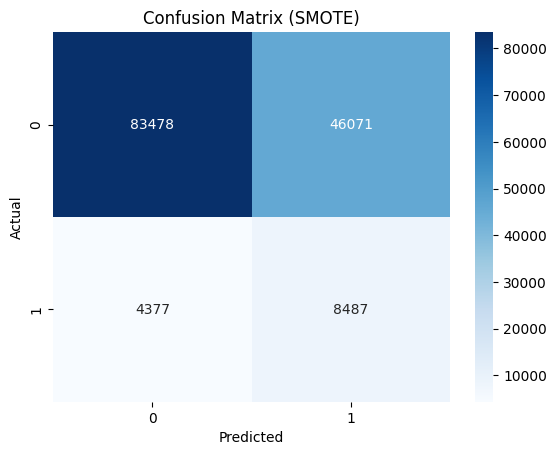

In [31]:
# Use the confusion matrix function from sklearn.metrics for the SMOTE model to show counts of TP, FP, TN, FN.
conf_matrix = confusion_matrix(y_test, y_pred_smote)

# plot the confusion matrix as a heatmap for clear visual interpretation
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

# add title and axis labels for clarity
plt.title("Confusion Matrix (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# render the plot
plt.show()

The confusion matrix displays the number of correct and incorrect predictions for both *late-filing* and *on-time* companies, where the negative class represents *on-time* filings and the positive class represents *late-filings*.
- **Test Population:** 142,413 (The total number of companies in the test population *on-time* and *late*)
- **Total Negatives:** 127,549 (The total number of *on-time* companies in the test population)
- **Total Positives:** 12,864  (The total number of *late-filing* companies in the test population)
<br><br>
**Confusion Matrix Results:**
- **True Negatives:**  83,440  (The number of *on-time* companies correctly identified as *on-time*)
- **False Positives:** 46,109  (The number of *on-time* companies incorrectly flagged as *late*)
- **False Negatives:**  4,377  (The number of *late-filing* companies the model failed to detect)
- **True Positives:**   8,487  (The number of *late-filing* companies correctly identified as *late*)

These values align with the model's precision and recall scores and illustrate the practical *trade-off* of prioritising recall over precision.

**A reminder of the *SMOTE* metrics:**
| Precision | Recall | F1 | ROC-AUC|
|------|------|------|-------|
| 0.155451 | 0.659748 |	0.251616 | 0.718224 |


The model successfully identifies **8,487 late-filing companies**, capturing around **65.97%** of all *late-filers* in the test population. This reflects the model's high recall, which is the primary performance priority for this project. Only **4,377 *late-filers* are missed (~34.03%)** a substantial improvement on the **~93.4%** that would have been missed in the baseline model (recall was **~0.066** for the *baseline model*).

This demonstrates that the model is effective at detecting *late-filing* companies (**~66%** true positives) although it does miss some (**4,377 = ~34%** false negatives), consistent with the earlier recall calculation **(~0.660759)**.

The model also produces **46,109 false positives**, meaning a large number of compliant companies are incorrectly flagged as late. This is consistent with the precision score of **~0.155**, indicating that only a minority of flagged companies are genuinely *late*. However, given the imbalance between *late* and *on-time* filings, predicting a rare event (*late*) inevitably generates many false positives. In a business or regulatory context, this may be acceptable, where the cost of missing *late-filers* outweighs the adminitrative effort of reviewing additional *on-time* companies that were incorrectly flagged as *late*.

Overall this confusion matrix shows that the *SMOTE* model is effective at identifying *late-filing* companies, even though it incorrectly flags many *on-time* companies as *late* during the process. This is the trade-off when dealing with imbalanced datasets where catching the minority-class (*late-filers*) is the priority.

## 13. Precision-Recall Curve.
A precision-recall curve can be used to visualise the *SMOTE* model's precision/recall change as the classification threshold changes. It shows precision (how many of the predicted positives were correctly flagged) against recall (how many true positives the model found) across different thresholds. Below is the precision-recall curve for the model. This graph supports analysis of how the precision and recall trade-off with each other as the threshold changes.
- **Precision** = What proportion did we get right? Of all the *lates* that were predicted, what proportion did we get right?
- **Recall** = What proportion of real positives did we get right? Of all the companies that were actually *late* what proportion did we predict?
- **F1** = The average of **precision** and **recall** (the harmonic mean).

A perfectly straight line y=-x would indicate that precision and recall were perfectly inversely proportional, as one increases the other decreases at the same rate.

In [32]:
# generate an interactive precision–recall curve for the SMOTE logistic regression model
# using the 'plot_interactive-_pr_curve' helper function from 'visualisations.py'
plot_interactive_pr_curve(
    y_true=y_test,
    y_prob=y_prob_smote,
    title="SMOTE Logistic Regression Precision–Recall Curve",
    save_prefix="smote_pr_curve"
)

The curve above is a method for visualising the trade-off between *precision* and *recall*, displaying how catching more positives (improving *recall*) means that more false positives are also captured (*precision* drops).

If the plot did not display then please click the image below: <br>

<center><a href="smote_pr_curve.html"><img src="smote_pr_curve.png" alt="Static Plot" width="100"></a><center>
Static Preview (click for interactive version) <br>
WARNING: You may have to download the html file then open the downloaded file to use. <br><br>

In this curve *precision* drops sharply as the low *recall* numbers increase which is reflected in the low **PR-AUC** (the **A**rea **U**nder the Precision Recall **C**urve) value of **~0.309**. The low *precision* (**~155**) and high *recall* (**~0.66**) of the model fits in with the curve above, and validates that we can choose high *precision* or high *recall* but not at the same time.

To choose the best threshold to use for the modelling I will conduct some threshold tuning and use the **F1** metric as a decision factor, looking at the balance of *precision* and *recall*.

## 14. Threshold Tuning

Logistic regression outputs a probability score between **0** and **1**, which represents the model’s estimated likelihood that a company will file its accounts late. The default decision threshold of **0.50** assumes equal misclassification costs and balanced classes of *on-time* and *late* companies. However, this dataset is a highly imbalanced dataset because *late-filing* (the minority class) is **9.03%**. Therefore, using the default threshold leads to high recall but extremely low precision for the positive class, producing an excessive number of false positives (those who the model claims will file late but who in fact don't).

To address this I will perform threshold tuning to explore the *trade‑off* between *precision* and *recall* across a range of probability *cut‑offs*. Evaluations different thresholds starting with **0.50** to show that the original *SMOTE* model that used this threshold returns the same numbers here. Then I will increase in increments of **0.05** until **0.80** (**0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80**).

For each threshold, *precision, recall, F1‑score*, and *confusion‑matrix counts* are re-calculated using the model’s predicted probabilities on the test set. Then the results are displayed in a dataframe for comparison.

In [33]:
# Create a threshold evaluation helper function that generates a threshold matrix
def evaluate_thresholds(y_true, y_prob, thresholds):
    results = []                                                # container for metrics across thresholds

    for t in thresholds:                                        # iterate through each threshold
        y_pred_t = (y_prob >= t).astype(int)                    # convert probabilities to class predictions

        prec = precision_score(y_true, y_pred_t)                # compute precision at threshold t
        rec = recall_score(y_true, y_pred_t)                    # compute recall at threshold t
        f1 = f1_score(y_true, y_pred_t)                         # compute F1 score at threshold t
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()  # extract confusion‑matrix counts

        results.append({                                        # store all metrics for this threshold
            "threshold": t,
            "precision": prec,
            "recall": rec,
            "F1": f1,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })

    return pd.DataFrame(results)                                # return results as a DataFrame

In [34]:
thresholds_1 = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]         # Define the thresholds to use
threshold_df_1 = evaluate_thresholds(y_test, y_prob_smote, thresholds_1)     # Generate the threshold matrix.
threshold_df_1

,threshold,precision,recall,F1,TP,FP,FN,TN
0,0.50,0.155559,0.659748,0.251758,8487,46071,4377,83478
1,0.55,0.173056,0.588153,0.267425,7566,36154,5298,93395
2,0.60,0.230755,0.395445,0.291443,5087,16958,7777,112591
3,0.65,0.317370,0.291589,0.303934,3751,8068,9113,121481
4,0.70,0.414102,0.230100,0.295823,2960,4188,9904,125361
5,0.75,0.609018,0.165889,0.260753,2134,1370,10730,128179
6,0.80,0.657555,0.134639,0.223513,1732,902,11132,128647


The goal here is to choose the probability *cut-off* that gives the best balance between *precision* and *recall* for the problem, which is to identify as many *late-filing* companies as possible. That means that ***recall* and *F1* are the key metrics** and *precision* is less important. **Missing the opportunity to identify *late-filers* is worse than mislabelling a compliant company and adding the administrative costs of validating that they were in fact not a late-filer.**

The  results show a clear pattern, that lower thresholds **(0.50 - 0.55)** produced higher recalls **(~0.59 - ~0.66)** but very low *precision* **(~0.155 - ~0.173)**, meaning the model identified many *late-filers* but at the cost of a large number of false alarms **(FP ~36k - ~46k)**. Increasing the threshold improved *precision* but reduced *recall*. At a threshold of **0.8**, precision rose to **~0.658**, but recall fell to **~0.135**, indicating that the model only flagged cases where it was extremely confident, missing the majority of late filers.

At a threshold of **0.65** the **F1 score** is the highest, meaning that this threshold provides the most balanced performance. At this level *precision* was **~0.32**, recall was **~0.29** and false positives were **~8,068**. This threshold only catches **~29%** of *late-filers* even though the false positives significantly reduced compared to the two lower thresholds (**0.5 = ~46kFP, 0.55 = ~36kFP**). This would be a valid option to choose, however the goal is to identify as many late filers as possible, therefore it will be rejected in this case.

There could be a case for deciding upon either **0.50** or **0.55** as the threshold to use. For a **TP** reduction of **less than 1k** there is also a reduction in **FP** of **~10k** between the two options. Therefore one method would be to present a more granular breakdown of this to stakeholders for a deeper dive into the decision making, to assess whether a more suitable option exists between the two. 

Overall, threshold tuning highlights the difficulty in choosing what is most important to a model.
- Is success based on precision (ensuring a higher proportion of the predicted *late-filers* are correctly identified but identifying fewer *late-filers*)
- Is success based on recall (ensuring more *late-filers* are predicted but also accepting that a higher proportion of them will be flagged incorrectly).

Here I will repeat the process in steps of **0.01** for **0.45 - 0.55**.

In [35]:
thresholds_2 = [0.45, 0.46, 0.47, 0.48, 0.49, 0.50, 0.51, 0.52, 0.53, 0.54, 0.55]             # Define the thresholds to use
threshold_df_2 = evaluate_thresholds(y_test, y_prob_smote, thresholds_2)   # Generate the threshold matrix.
threshold_df_2

,threshold,precision,recall,F1,TP,FP,FN,TN
0,0.45,0.134368,0.774098,0.228988,9958,64152,2906,65397
1,0.46,0.136370,0.764770,0.231466,9838,62304,3026,67245
2,0.47,0.143736,0.724502,0.239882,9320,55521,3544,74028
3,0.48,0.143999,0.723803,0.240209,9311,55349,3553,74200
4,0.49,0.148357,0.692553,0.244367,8909,51142,3955,78407
5,0.50,0.155559,0.659748,0.251758,8487,46071,4377,83478
6,0.51,0.156195,0.656639,0.252360,8447,45633,4417,83916
7,0.52,0.167234,0.603312,0.261877,7761,38647,5103,90902
8,0.53,0.167565,0.601835,0.262143,7742,38461,5122,91088
9,0.54,0.167811,0.600280,0.262296,7722,38294,5142,91255


All thresholds in this range successfully identify over half of all *late-filers* as *recall* **above 0.5**. However this is at the cost of identifying a large number of **false positives**, which is the expected *trade-off* when prioritising recall.

Based on these results, personal judgment here is that **0.52** is a good threshold to choose, it still catches **~60.3%** of *late-filers* with a large reduction in *false-positives* (**~7,400 fewer**) from the original **0.5** threshold used earlier. With true positives only falling by **~726** to **7,761**, this seems like an acceptable threshold to choose. In a business context this would be decided upon by stakeholders determining how much resource they have to handle both groups (*TP* and *FP*). Selecting **0.52** represents a sensible compromise between identifying *late-filers* and maintaining an acceptable *false‑positive* rate.

Now I will display this visually to make a final decision before interpreting coefficients.

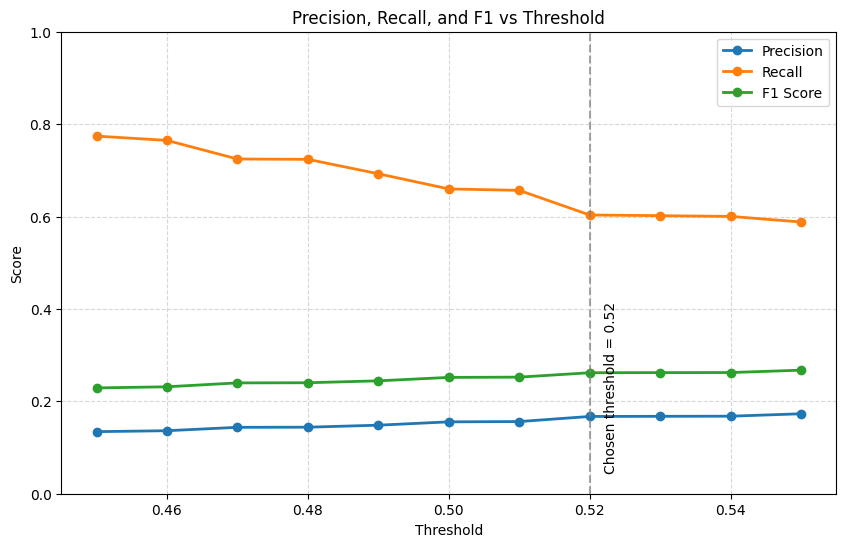

In [36]:
threshold_df = threshold_df_2    # Ensure this is using the last dataframe produced.
thresholds = threshold_df["threshold"]                     # extract threshold values for plotting
precisions = threshold_df["precision"]                     # extract precision scores across thresholds
recalls = threshold_df["recall"]                           # extract recall scores across thresholds
f1s = threshold_df["F1"]                                   # extract F1 scores across thresholds

plt.figure(figsize=(10, 6))                                # create plotting area with defined size

plt.plot(thresholds, precisions, marker='o', label='Precision', linewidth=2)   # plot precision vs threshold
plt.plot(thresholds, recalls, marker='o', label='Recall', linewidth=2)         # plot recall vs threshold
plt.plot(thresholds, f1s, marker='o', label='F1 Score', linewidth=2)           # plot F1 vs threshold

chosen = 0.52                                               # define the chosen threshold to highlight
plt.axvline(chosen, color='grey', linestyle='--', alpha=0.7)                   # draw vertical reference line
plt.text(chosen + 0.002, 0.05, f"Chosen threshold = {chosen}", rotation=90)    # annotate the chosen threshold

plt.title("Precision, Recall, and F1 vs Threshold")         # add plot title
plt.xlabel("Threshold")                                     # label x-axis
plt.ylabel("Score")                                         # label y-axis
plt.ylim(0, 1)                                              # fix y-axis range for comparability
plt.grid(True, linestyle='--', alpha=0.5)                   # add grid for readability
plt.legend()                                                # display legend

plt.show()                                                  # render the plot

This graph shows the *precision*, *recall* and *F1* scores for the thresholds calculated above, along with the chosen threshold of **0.52**, which provided balanced trade-off between identifying *late-filers* and limiting *false-positives*. The best threshold is *use case dependent*, and so options should be presented to stakeholders. For purposes of this analysis **0.52** will be used and I will move on to interpretting coefficients.

## 15. Interpretation of Coefficients.
Here I observe which variables increase/decrease risk. <br>
This converts to odds ratios for interpretation.

In [37]:
# access the preprocessor -> categorical transformer -> extract encoded feature names
ohe_features = (
    pipeline_smote.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(categorical_cols)
)

all_features = numeric_cols + list(ohe_features)                 # combine numeric and encoded categorical feature names

coefficients = pipeline_smote.named_steps['model'].coef_[0]      # extract logistic regression coefficients in model order

coef_df = pd.DataFrame({                                         # build a table of features, coefficients, and odds ratios
    'feature': all_features,
    'coefficient': coefficients,
    'odds_ratio': np.exp(coefficients)
}).sort_values(by='odds_ratio', ascending=False)                 # sort by odds ratio to highlight strongest effects

coef_df                                                          # display the coefficient table

,feature,coefficient,odds_ratio
2,company_category_PLC,1.768854,5.864128
0,company_category_LTD,1.499302,4.478561
20,company_age_when_acc_due_2–5,1.465520,4.329793
21,company_age_when_acc_due_5–10,1.374215,3.951972
3,registered_country_UNKNOWN,1.258369,3.519675
1,company_category_LTD BY GUARANTEE/CIC,0.713220,2.040550
18,company_age_when_acc_due_10–20,0.332476,1.394417
15,industry_Transport & Storage,0.157671,1.170781
16,industry_UNKNOWN,-0.068726,0.933582
22,has_corporate_psc_1,-0.104249,0.901001


Risk-factors (features) that **increase the odds** of *late-filing* have **positive coefficients** and odds-ratios **greater than 1**. There are **8** of these features in this model. Conversely risk-factors that **decrease the odds** of *late-filing* have **negative coefficients** and odds-ratios **less than 1**, and there are **17** of these in this model.

**Top 5 Risk Factors:** 
1. *company_category_PLC* (odds-ratio = 5.86): The strongest predictor of the model. PLC companies are almost **6 times more likely** to file *late* than the baseline group.
2. *company_category_LTD* (odds-ratio = 4.48): LTD companies are roughly **4.5 times as likely** to file late.
3. *company_age_when_acc_due_2-5* (odds-ratio = 4.33): Companies aged **2-5 years** are **over 4 times more likely** to file late.
4. *company_age_when_Acc_due_5-10* (odds-ratio = 3.95): Companies aged **5-10 years** are **nearly 4 times more likely** to file late.
5. *registered_country_UNKNOWN* (odds-ratio = 3.52): Companies where the registered country is UNKNOWN are **around 3.5 times more** likely to file late.

**Bottom 5 Risk Factors:**
1. *has_any_psc_1* (odds-ratio = 0.007129): Companies with at least **1 PSC** are have dramatically lower offs of filing late. This is the strongest predictive factor in the model, reducing the odds of filing late by more than **99%** compared to companies with *no PSCs*.
2. *industry_Real Estate* (odds-ratio = 0.26): Companies in the Real Estate sector are around **74% less likely** to file late.
3. *industry_Public & Non-Market* (odds-ratio = 0.37): Companies in the Public & Non-Market sectors show around **63% lower odds** of filing late.
5. *industry_Finance & insurance* (odds-ratio = 0.374). Firms in the Finance and Insurance sector are about **62.5%** less likely to file late.
6. *industry_Professional, Scientific & Tech* (odds-ratio = 0.391). Organisation in the Professional, Scientific & Tech industries are approximately **61%** less likely to file late.

**Meaning:**
The model suggests that *PLC and LTD companies; companies between the ages of **2-10 years old** when the accounts are due; companies with an unknown registered country* are more likely to file accounts late than companies outside of these categories. PLCs, in particular, are almost **six times** more likley to file *late* making legal form one of the strongest predictors of non-compliance. LTD companies also show a higher risk. Younger and mid-aged companies exhibit a four fold increase in late filing suggesting that they lack mature administrative processes, as age groups increase the odds of filing late decrease, as shown in the table above. Missing data in terms of the registered country, may be due to poor record keeping or low engagement with compliance, making them **approximately 3.5 times more** likely to file late.

The model suggests that companies with **at least one PSC**; and those in several industry sectors (*Real Estatem Public & Non-MArket, Finance & Insurance,* and *Professional, Scientific & Technical* services) show a significantly reduced risk of filing late. These sectors may benefit from more tightly controlled administrative processes within their company nature, which could see them requiring accountants and solicitors due to the added rules and regulations that these types of companies must follow, meaning and increasing likelihood that accountants and solicitors work for the companies and handle the accounts. Unknown industry is a surprise addition here as one may assume that missing information may be an indicator of non-compliance, however it could be due to changing industries in the modern-age with social media and AI expansions and a changing jobs market, or hybrid business models that do not fit traditional business classifications.

Overall the strongest predictors of late-filing are **PLC/LTD** companies aged between **2 and 10 years** with **missing registered country**, while the companies with the lowest risk of late-filing are those with **at least one PSC** operating in **regulated or professional sectors**.

Next I will plot a feature importance graph which plots the absolute logistic regression coefficients and ranks the featues by importance. This gives a visual representation of which features are the most important to a model regardless of whether they increase or decrease the risk of a company filing late.

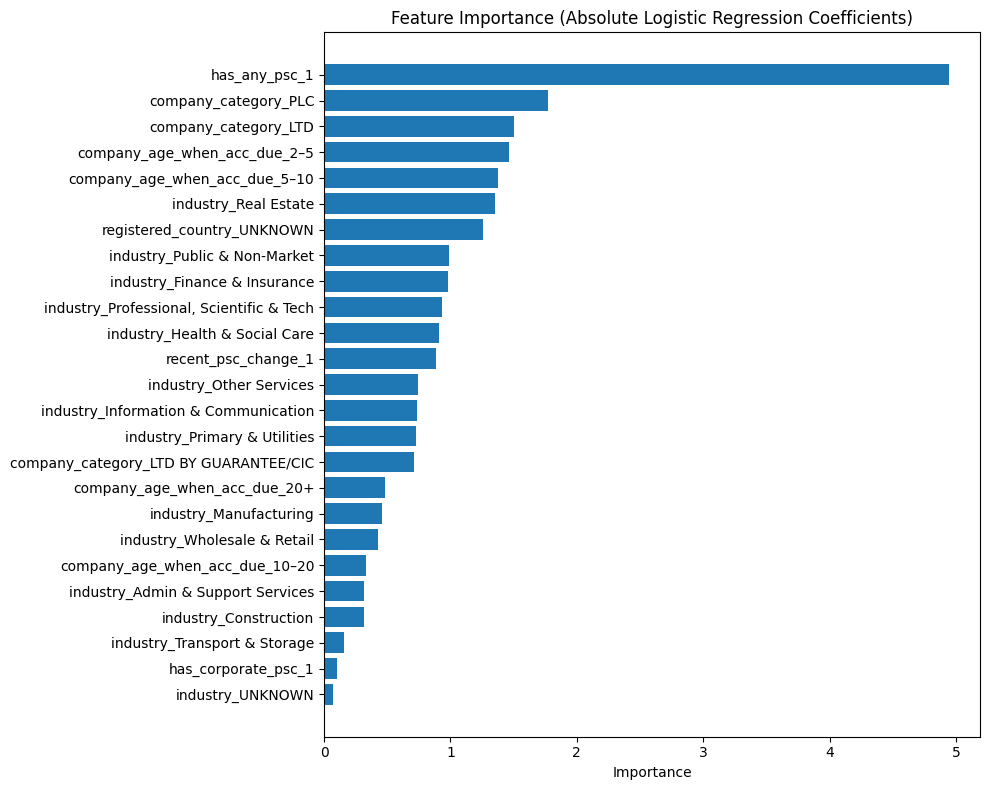

In [38]:
coef_df_sorted = coef_df.copy().sort_values(                 # create a sorted copy of the coefficient table
    by='coefficient', key=np.abs, ascending=True             # sort by absolute coefficient magnitude (small -> large)
)

plt.figure(figsize=(10, 8))                                  # create plotting area with defined size

plt.barh(                                                    # draw horizontal bars for feature importance
    coef_df_sorted['feature'],
    coef_df_sorted['coefficient'].abs()
)

plt.title("Feature Importance (Absolute Logistic Regression Coefficients)")   # add plot title
plt.xlabel("Importance")                                     # label x-axis
plt.tight_layout()                                           # adjust layout to avoid label clipping
plt.show()                                                   # render the plot

This chart shows the features that have the largest down to the lowest absolute impact on the model’s predictions, ranking each predictor based on the strength of its influence on the model, regardless of whether it increases or decreases the odds of filing late. Features with larger absolute coefficients indicate a stronger contribution to the model's decision making.

The most influential predictors are having **at least one PSC**, being a **PLC or LTD** company, being between the ages of **2 and 10** when accounts are due. This highlights that company ownership structure and maturity play substantial roles in shaping filing behaviour.

Mid-ranked predictors include **recent PSC changes** and various industry sectors that traditionally encounter large administrative regulations.

Lower-ranked predictors include those with a **corporate PSC**, in **unknown, construction and transport/storage industries**. Their smaller coefficients suggest that these features have comparatively weaker effects on the likelihood of a company *late-filing*.

This analysis supports the original hypothesis to some extent:
- Company structure variables such as company category (PLC, LTD), company age, and registered country information are strong predictors of late filing behaviour. These structural characteristics show large positive coefficients and high odds-ratios, indiciating substantially increased risk.
- Ownership variables (PSC-related features) also demonstrate predictive value, but their influence is generally much weaker than structural and industry variables, **with one major exception**. The presence of **at least one PSC** is the single strongest protective factor in the entire model, as demonstrated by the large bar in the chart above. Haivng at least one PSC reduces the odds of late-filing by more than **99%** compared to companies with **no PSCs**. This suggests that ownership characteristics matter.

## 16. Into Production

In a production environment, the model would receive new company records and automatically apply the same preprocessing steps used during training via the *scikit‑learn* pipeline. The logistic regression model would then generate a probability of *late-filing* for each company. A threshold of **0.52** would be applied to convert this probability into a binary risk flag, allowing compliance teams to prioritise companies most likely to file *late*. The system could be integrated into a batch ETL workflow, an API‑driven service, or a dashboard, and would be retrained periodically to reflect changes in filing behaviour.

As a stratified sample of the original population was used in the training of the model I have a large population of data unseen by the model to use in this productionising step.
- Starting population = **~2.8 million**
- 25% sample data **~712k** (this data was used in the model building, this is the test/train data)
- 75% discarded data = **~2,14 million** (this data was not used at any stage of the model development and is therefore treated as unseen data for the purposes of applying the model to new data).

**Note:** This is not *"future"* data and ideally fresh data could be sourced with new companies not in the downloaded data at all however for the purposes of this analysis the discarded data will be used.

Next I use *df_discard*, running the model on that data to produce a risk-score for all companies that weren't in the sample dataset, this can then be used to segment the population into risk-bandings.
- **Very High Risk: top 5% of companies**
- **High Risk:  top 10% of companies - top 5% of companies**
- **Medium Risk: top 20% of companies - top 10% of companies**
- **Low Risk: Bottom 80% of companies**

When risk-bandings have been produced the characteristics of the group can then be produced to look at the profile of the highest risk population, reporting on the breakdown of the population per dominating feature. Answering questions such as:
- How many are in each registered company type?
- Are they mostly younger companies? How many companies are in each age bracket?
- Which industries do they tend to fall into (e.g. retail.)

In [39]:
# Rename the data for clarity of purpose
df_unseen = df_discard.copy()
print_dataset_shape(df_unseen)

# separate the features from the target
x_unseen = df_unseen.drop(columns=[target])     # define x_unseen which contains all predictor/feature variables.
y_unseen = df_unseen[target]                    # define y_unseen which contains only the target variable

rows: 2,136,192
columns: 10


Apply the same feature engineering function for consistency with the training model.

In [40]:
x_unseen = log_reg_feature_engineering(x_unseen)

rows: 2,136,192
columns: 7


In [41]:
# Generate predicted probabilities by passing the unseen data (x_unseen)through the chosen pipeline
df_unseen['late_prob'] = pipeline_smote.predict_proba(x_unseen)[:,1]

# Apply the tuned 'chosen' threshold from earlier
Threshold = chosen
df_unseen['predicted_late'] = (
    df_unseen['late_prob'] >= Threshold
).astype(int)

# Inspect the highest risk companies
df_unseen.sort_values("late_prob", ascending = False).head(8)

,company_category,accounts_group,registered_country,industry,company_age_when_acc_due,psc_count,has_corporate_psc,has_foreign_psc,recent_psc_change,overdue,late_prob,predicted_late
2069386,PLC,FULL,UNKNOWN,Transport & Storage,2–5,0,0,0,0,1,0.999400,1
2772865,PLC,FULL,UNKNOWN,Transport & Storage,2–5,0,0,0,0,1,0.999400,1
2022035,PLC,FULL,UNKNOWN,Transport & Storage,2–5,0,0,0,0,1,0.999400,1
223582,PLC,FULL,UNKNOWN,Transport & Storage,5–10,0,0,0,0,1,0.999343,1
2471417,PLC,FULL,UNKNOWN,UNKNOWN,2–5,0,0,0,0,1,0.999248,1
328273,PLC,FULL,UNKNOWN,UNKNOWN,2–5,0,0,0,0,1,0.999248,1
2288274,PLC,FULL,UNKNOWN,UNKNOWN,2–5,0,0,0,0,1,0.999248,1
1333120,PLC,FULL,UNKNOWN,UNKNOWN,2–5,0,0,0,0,1,0.999248,1


The table above shows information for the **top 8** companies predicted to file *late*, they are all in the *PLC* company category, aged **2 - 5 years** or **5 - 10 years** in the ***Transport & Storage* or *UNKNOWN*** industries, with an **unknown registered country**, and **no PSCs**. They were predicted by the model to be late, with a late probability of **99.9%** and can be confirmed that they are in fact *late-filers* by looking at the *overdue* column. Comparing each of these variables to the coefficients table above it can be seen that they all sit at the top of the table for their variables types, with the exception of the **no PSC** column which must be inferred from the **has_any_PSCs** variable being at the bottom of the coefficients table.

This check provides strong validation that the model is working, and the pattern aligns closely with the eariler coefficient and odds-ratio analysis. Younger companies, missing registered country information in certain industries with no PSCs were more likely to file late.

Now I will create risk bandings for the population based on:
- **Very High Risk: top 5% of companies**
- **High Risk:  top 10% of companies - top 5% of companies**
- **Medium Risk: top 20% of companies - top 10% of companies**
- **Low Risk: Bottom 80% of companies**

In [42]:
# Create risk bandings discussed above.
# Take the top 10% riskiest companies and the top 20% riskiest companies.
# Create a 'risk_band' column in df_unseen flagging all companies as 'Low' for 'risk_band'
# Change the 'risk_band' flag to 'High' for the top 10% riskiest companies
# Then change those that are in the top 20% but not in the top 10% as 'Medium' risk.

top_5pc_cutoff = df_unseen['late_prob'].quantile(0.95)  # Get the top 5 percent of companies most likely to file late
top_10pc_cutoff = df_unseen['late_prob'].quantile(0.90) # Get the top 10 percent of companies most likely to file late
top_20pc_cutoff = df_unseen['late_prob'].quantile(0.80) # Get the top 20 percent of companies most likely to file late
df_unseen['risk_band'] = '4. Low Risk'                     # Generate a new column called risk which has a default value of "Low"

 # Redefine the risk band for the riskiest 10% of companies as High.
df_unseen.loc[df_unseen['late_prob'] >= top_5pc_cutoff, 'risk_band'] = '1. Very High Risk'

# Redefine the risk band for the companies in the top 10pc of riskiest companies but lower than the top 5% of riskiest companies as Medium.
df_unseen.loc[(df_unseen['late_prob'] >= top_10pc_cutoff) & (df_unseen['late_prob'] < top_5pc_cutoff), 'risk_band'] = '2. High Risk'

# Redefine the risk band for the companies in the top 20pc of riskiest companies but lower than the top 10% of riskiest companies as Medium.
df_unseen.loc[(df_unseen['late_prob'] >= top_20pc_cutoff) & (df_unseen['late_prob'] < top_10pc_cutoff), 'risk_band'] = '3. Medium Risk'

# count of companies per band
print("Count of Companies per", df_unseen['risk_band'].value_counts().sort_index().to_string(), "\n")

Count of Companies per risk_band
1. Very High Risk     144269
2. High Risk           78622
3. Medium Risk        206590
4. Low Risk          1706711 



The risk bandings that have been attached to the population would allow Companies House to choose companies from the highest risk-bands to conduct compliance support activity.

Next I will pull out the profile of the very high-risk group, showing how many companies are within each category per variable, reporting on the breakdown of the population per dominating feature. Answering questions such as:
- How many are in each registered company type?
- Are they mostly younger companies? How many companies are in each age bracket?
- Which industries do they tend to fall into (e.g. retail.)

In [43]:
# Profile the high-risk group
very_high_risk = df_unseen[df_unseen['risk_band'] == '1. Very High Risk'] # Pull out the high-risk population

# Get the distribution of key features.
print("Count of", very_high_risk['company_category'].value_counts().to_string(), "\n")
print("Count of", very_high_risk['industry'].value_counts().to_string(), "\n")
print("Count of", very_high_risk['company_age_when_acc_due'].value_counts().to_string(), "\n")
print("Count of", very_high_risk['registered_country'].value_counts().to_string(), "\n")

Count of company_category
LTD                     143279
PLC                        645
LTD BY GUARANTEE/CIC       305
LLP                         40 

Count of industry
Accommodation & Food               48214
Transport & Storage                43179
Wholesale & Retail                 10416
Professional, Scientific & Tech     7538
Construction                        6263
Admin & Support Services            5619
Information & Communication         5008
Other Services                      4657
Manufacturing                       3949
Finance & Insurance                 2471
Public & Non-Market                 2249
UNKNOWN                             1964
Health & Social Care                1665
Primary & Utilities                 1002
Real Estate                           75 

Count of company_age_when_acc_due
2–5      82255
5–10     49593
10–20     9786
20+       2629
0–2          6 

Count of registered_country
UNKNOWN             67599
ENGLAND             50011
UK                  20

#### Questions:
A raft of questions could be asked about the data, here are some just to show the use case of this high-risk profile.
- How many are in each registered country type? (answer *UNKNOWN* as an example here)
  - There are **67,599** companies in the *UNKNOWN* registered country.
- Are they mostly younger companies? How many companies are in each age bracket?
  - Most companies in the very high risk group are aged **2 - 10 years**.
- Which industries do they tend to fall into (e.g. retail.)
  - Most of the very high-risk companies fall into the *Accommodation and Food, Transport & Storage, Wholesale & Retail* industries.

**Note:** If the original company_number had been retained throughout then I could pull out the Very High Risk population to save off for reporting and further analysis, however as this is being published to *github* I chose to remove and disguise company number for the purposes of this analysis for ethical reasons, and will leave this analysis here.

## 17. Conclusion

This project builds a complete logistic regression pipeline to predict whether a company will file its accounts *late* using Companies House data. After an initial exploratory analysis, I reduced the dataset to a clean, interpretable set of **nine** predictor variables and **one** binary target variable, ensuring that every feature described company behaviours and offered predictive value to the model. Some variables were removed during EDA because they offered no variation or discriminatory power and removing them prevented noise and distortion of the model.
- **company_number**, a unique identifier with no behavioural relevance;
- **country_of_origin**, which contained only a single value for all companies;
- **has_sanctioned_psc**, which had zero positive cases.
- **accounts_category**, was removed as it showed no variation in the late-filing rates (**8–10%** across all groups);
- **has_foreign_psc** was also removed due to very limited predictive power, late filing rates (**9-10%**);
- **PSC count** was removed after engineering into a new feature variable **has_any_pscs** due to the overwhelming influence of *no PSCs* compared to *any number of PSCs*.

The remaining features were retained because they showed clear behavioural patterns and strong operational relevance to the model.
- **company_category** was grouped into meaningful legal forms, each showing distinct late‑filing behaviour.
- **company_age_when_acc_due** was binned into real‑world age bands, revealing a non‑linear relationship where younger companies were more likely to file late.
- **industry** was reduced to a manageable set of categories and showed substantial variation in late‑filing rates, reflecting differences in seasonality, governance, and professional oversight.
- **registered_country** was engineered into a simple UNKNOWN vs KNOWN UK flag, with the UNKNOWN group showing noticeably different behaviour.
- **has_any_pscs** was created from the original **PSC count** to isolate companies with no PSCs — a tiny but extremely *high‑risk* group.
- **has_corporate_psc and recent_psc_change**  were retained because each showed clear behavioural separation and strong interpretability.
- The target variable, **overdue**, remained in its natural imbalanced form (**90.97%** *on‑time*, **9.03%** *late*) to preserve the real‑world filing behaviour.

I trained three versions of the logistic regression model:
- a *baseline* model on the raw imbalanced data,
- a *class‑weighted* model that increased the penalty for misclassifying *late-filers*,
- a *SMOTE* model that generated synthetic minority‑class (*late*) examples to balance the training set.

Model performance for all **3** models was evaluated using *precision*, *recall*, *F1*, *AUC*, and detailed threshold adjustment analysis to understand how different probability *cut‑offs* could affect operational decisions. The *SMOTE* with a threshold of **0.52** was selected based on this analysis.

After selecting the final model, I extracted *coefficients*, *odds-ratios*, and *feature importance rankings* using the test dataset. This enabled me to interpret which engineered and original features most strongly influenced *late‑filing* behaviour.

Finally, the best‑performing model (*SMOTE* with a threshold of **52%**, with the feature engineering pipeline defined from the training dataset) was applied to unseen Companies House data to generate *late‑filing* probabilities for every company in the unseen dataset. Using *percentile‑based thresholds*, I assigned companies to *Very-High Risk*, *High-Risk*, *Medium-Risk*, and *Low-risk* bandings. These bandings could be used to identify populations for supportive targetted compliance activity, prioritisation and monitoring.

Overall, this project delivers a complete, interpretable, end‑to‑end modelling workflow; from feature selection and engineering through to model training, evaluation, interpretation, and practical risk scoring. This analysis demonstrates how company-level structure and behavioural variables can be used to predict regulatory non-compliance in the UK Companies House population.

**The original question asked:
"To what extent can company structure and ownership variables be used to predict late-filing behaviour in UK companies, using logistic regression, as an indicator of regulatory non-compliance?". With the working hypotheses that they could predict very well.**

The findings **support the hypothesis**, more so in some ways and less so in others. Company structure variables such as legal form, company age, registered-country information and industry provide the strongest and most reliable predictors of late-filing behavour. These structural characteristics consistently show large effects and dominate the model’s explanatory power. Ownership variables (**PSC‑related** features) also contribute meaningful information, but their predictive influence is much **weaker** than that of the structural and industry characteristics. Overall, the model demonstrates that **company structural and ownership variables can be used to predict late filing**, confirming the hypothesis. However, the analysis also reveals that **broader organisational features**, particularly industry and company maturity, play an even larger role than originally anticipated, while ownership plays a smaller role than expected, aside from the **exceptionally strong protective effect of having at least one PSC**.